pandas
matplotlib
seaborn
pip
openpyxl

##### Import

In [116]:
import pandas as pd

b_df = pd.read_excel('bangalore_cars.xlsx')
c_df = pd.read_excel('chennai_cars.xlsx')
d_df = pd.read_excel('delhi_cars.xlsx')
h_df = pd.read_excel('hyderabad_cars.xlsx')
j_df = pd.read_excel('jaipur_cars.xlsx')
k_df = pd.read_excel('kolkata_cars.xlsx')

##### Add City

In [117]:
b_df['City'] = 'Bangalore'
c_df['City'] = 'Chennai'
d_df['City'] = 'Delhi'
h_df['City'] = 'Hyderabad'
j_df['City'] = 'Jaipur'
k_df['City'] = 'Kolkata'

##### Concat

In [118]:
df_merged = pd.concat([b_df, c_df, d_df, h_df, j_df, k_df], ignore_index=True)

In [4]:
df_merged.shape

(8369, 6)

##### Unstructured to Structured

In [62]:
df_merged.head(1)

,new_car_detail,new_car_overview,new_car_feature,new_car_specs,car_links,City
0,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...,Bangalore


In [6]:
df_merged.isnull().sum()

new_car_detail      0
new_car_overview    0
new_car_feature     0
new_car_specs       0
car_links           0
City                0
dtype: int64

New Car Detail Column

In [119]:
import ast

df_merged['new_car_detail'] = df_merged['new_car_detail'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df_new_car_detail = pd.json_normalize(df_merged['new_car_detail'])

In [8]:
df_new_car_detail.head()

,it,ft,bt,km,transmission,ownerNo,owner,oem,model,modelYear,centralVariantId,variantName,price,priceActual,priceSaving,priceFixedText,trendingText.imgUrl,trendingText.heading,trendingText.desc
0,0,Petrol,Hatchback,"1,20,000",Manual,3,3rd Owner,Maruti,Maruti Celerio,2015,3979,VXI,₹ 4 Lakh,,,None,https://stimg.cardekho.com/used-cars/common/ic...,Trending Car!,High chances of sale in next 6 days
1,0,Petrol,SUV,"32,706",Manual,2,2nd Owner,Ford,Ford Ecosport,2018,6087,1.5 Petrol Titanium BSIV,₹ 8.11 Lakh,,,None,https://stimg.cardekho.com/used-cars/common/ic...,Trending Car!,High chances of sale in next 6 days
2,0,Petrol,Hatchback,"11,949",Manual,1,1st Owner,Tata,Tata Tiago,2018,2983,1.2 Revotron XZ,₹ 5.85 Lakh,,,None,https://stimg.cardekho.com/used-cars/common/ic...,Trending Car!,High chances of sale in next 6 days
3,0,Petrol,Sedan,"17,794",Manual,1,1st Owner,Hyundai,Hyundai Xcent,2014,1867,1.2 Kappa S Option,₹ 4.62 Lakh,,,None,https://stimg.cardekho.com/used-cars/common/ic...,Trending Car!,High chances of sale in next 6 days
4,0,Diesel,SUV,"60,000",Manual,1,1st Owner,Maruti,Maruti SX4 S Cross,2015,4277,DDiS 200 Zeta,₹ 7.90 Lakh,,,None,https://stimg.cardekho.com/used-cars/common/ic...,Trending Car!,High chances of sale in next 6 days


In [9]:
df_new_car_detail.shape

(8369, 19)

New Car Overview Column

In [120]:
df_merged['new_car_overview'] = df_merged['new_car_overview'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

overview_dfs = []

for row in df_merged['new_car_overview']:
    keys = []
    values = []
    
    if row and 'top' in row and isinstance(row['top'], list):
        for item in row['top']:
            keys.append(item['key'])
            values.append(item['value'])
        
        temp_df = pd.DataFrame([values], columns=keys)
        overview_dfs.append(temp_df)
    else:
        overview_dfs.append(pd.DataFrame())

df_new_car_overview = pd.concat(overview_dfs, ignore_index=True)

df_new_car_overview.head()


,Registration Year,Insurance Validity,Fuel Type,Seats,Kms Driven,RTO,Ownership,Engine Displacement,Transmission,Year of Manufacture
0,2015,Third Party insurance,Petrol,5 Seats,"1,20,000 Kms",KA51,Third Owner,998 cc,Manual,2015.0
1,Feb 2018,Comprehensive,Petrol,5 Seats,"32,706 Kms",KA05,Second Owner,1497 cc,Manual,2018.0
2,Sept 2018,Comprehensive,Petrol,5 Seats,"11,949 Kms",KA03,First Owner,1199 cc,Manual,2018.0
3,Dec 2014,Comprehensive,Petrol,5 Seats,"17,794 Kms",KA53,First Owner,1197 cc,Manual,2014.0
4,2015,Third Party insurance,Diesel,5 Seats,"60,000 Kms",KA04,First Owner,1248 cc,Manual,2015.0


In [11]:
df_new_car_overview.shape

(8369, 10)

In [121]:
merged_df = pd.concat([df_new_car_detail, df_new_car_overview,  df_merged[['City']], df_merged[['car_links']]], axis=1)

merged_df.head()

,it,ft,bt,km,transmission,ownerNo,owner,oem,model,modelYear,...,Fuel Type,Seats,Kms Driven,RTO,Ownership,Engine Displacement,Transmission,Year of Manufacture,City,car_links
0,0,Petrol,Hatchback,"1,20,000",Manual,3,3rd Owner,Maruti,Maruti Celerio,2015,...,Petrol,5 Seats,"1,20,000 Kms",KA51,Third Owner,998 cc,Manual,2015.0,Bangalore,https://www.cardekho.com/used-car-details/used...
1,0,Petrol,SUV,"32,706",Manual,2,2nd Owner,Ford,Ford Ecosport,2018,...,Petrol,5 Seats,"32,706 Kms",KA05,Second Owner,1497 cc,Manual,2018.0,Bangalore,https://www.cardekho.com/buy-used-car-details/...
2,0,Petrol,Hatchback,"11,949",Manual,1,1st Owner,Tata,Tata Tiago,2018,...,Petrol,5 Seats,"11,949 Kms",KA03,First Owner,1199 cc,Manual,2018.0,Bangalore,https://www.cardekho.com/used-car-details/used...
3,0,Petrol,Sedan,"17,794",Manual,1,1st Owner,Hyundai,Hyundai Xcent,2014,...,Petrol,5 Seats,"17,794 Kms",KA53,First Owner,1197 cc,Manual,2014.0,Bangalore,https://www.cardekho.com/buy-used-car-details/...
4,0,Diesel,SUV,"60,000",Manual,1,1st Owner,Maruti,Maruti SX4 S Cross,2015,...,Diesel,5 Seats,"60,000 Kms",KA04,First Owner,1248 cc,Manual,2015.0,Bangalore,https://www.cardekho.com/used-car-details/used...


In [66]:
merged_df.shape

(8369, 31)

In [122]:
df = merged_df.copy()

##### Handling Missing Values

In [15]:
df.isnull().sum()

it                         0
ft                         0
bt                         0
km                         0
transmission               0
ownerNo                    0
owner                      0
oem                        0
model                      0
modelYear                  0
centralVariantId           0
variantName                0
price                      0
priceActual                0
priceSaving                0
priceFixedText          8369
trendingText.imgUrl        0
trendingText.heading       0
trendingText.desc          0
Registration Year         52
Insurance Validity         4
Fuel Type                  0
Seats                      6
Kms Driven                 2
RTO                      888
Ownership                 32
Engine Displacement        4
Transmission               0
Year of Manufacture       20
City                       0
dtype: int64

In [16]:
pd.set_option('display.max_columns', None)

In [17]:
df.head()

,it,ft,bt,km,transmission,ownerNo,owner,oem,model,modelYear,centralVariantId,variantName,price,priceActual,priceSaving,priceFixedText,trendingText.imgUrl,trendingText.heading,trendingText.desc,Registration Year,Insurance Validity,Fuel Type,Seats,Kms Driven,RTO,Ownership,Engine Displacement,Transmission,Year of Manufacture,City
0,0,Petrol,Hatchback,"1,20,000",Manual,3,3rd Owner,Maruti,Maruti Celerio,2015,3979,VXI,₹ 4 Lakh,,,None,https://stimg.cardekho.com/used-cars/common/ic...,Trending Car!,High chances of sale in next 6 days,2015,Third Party insurance,Petrol,5 Seats,"1,20,000 Kms",KA51,Third Owner,998 cc,Manual,2015.0,Bangalore
1,0,Petrol,SUV,"32,706",Manual,2,2nd Owner,Ford,Ford Ecosport,2018,6087,1.5 Petrol Titanium BSIV,₹ 8.11 Lakh,,,None,https://stimg.cardekho.com/used-cars/common/ic...,Trending Car!,High chances of sale in next 6 days,Feb 2018,Comprehensive,Petrol,5 Seats,"32,706 Kms",KA05,Second Owner,1497 cc,Manual,2018.0,Bangalore
2,0,Petrol,Hatchback,"11,949",Manual,1,1st Owner,Tata,Tata Tiago,2018,2983,1.2 Revotron XZ,₹ 5.85 Lakh,,,None,https://stimg.cardekho.com/used-cars/common/ic...,Trending Car!,High chances of sale in next 6 days,Sept 2018,Comprehensive,Petrol,5 Seats,"11,949 Kms",KA03,First Owner,1199 cc,Manual,2018.0,Bangalore
3,0,Petrol,Sedan,"17,794",Manual,1,1st Owner,Hyundai,Hyundai Xcent,2014,1867,1.2 Kappa S Option,₹ 4.62 Lakh,,,None,https://stimg.cardekho.com/used-cars/common/ic...,Trending Car!,High chances of sale in next 6 days,Dec 2014,Comprehensive,Petrol,5 Seats,"17,794 Kms",KA53,First Owner,1197 cc,Manual,2014.0,Bangalore
4,0,Diesel,SUV,"60,000",Manual,1,1st Owner,Maruti,Maruti SX4 S Cross,2015,4277,DDiS 200 Zeta,₹ 7.90 Lakh,,,None,https://stimg.cardekho.com/used-cars/common/ic...,Trending Car!,High chances of sale in next 6 days,2015,Third Party insurance,Diesel,5 Seats,"60,000 Kms",KA04,First Owner,1248 cc,Manual,2015.0,Bangalore


In [18]:
df.columns

Index(['it', 'ft', 'bt', 'km', 'transmission', 'ownerNo', 'owner', 'oem',
       'model', 'modelYear', 'centralVariantId', 'variantName', 'price',
       'priceActual', 'priceSaving', 'priceFixedText', 'trendingText.imgUrl',
       'trendingText.heading', 'trendingText.desc', 'Registration Year',
       'Insurance Validity', 'Fuel Type', 'Seats', 'Kms Driven', 'RTO',
       'Ownership', 'Engine Displacement', 'Transmission',
       'Year of Manufacture', 'City'],
      dtype='object')

In [19]:
df.it.value_counts()

it
0    8369
Name: count, dtype: int64

In [123]:
df.drop(['it', 'owner', 'centralVariantId', 'priceActual', 'priceSaving', 'trendingText.imgUrl',
       'trendingText.heading', 'trendingText.desc', 'Registration Year', 'Kms Driven', 'RTO',
       'Ownership', 'ft', 'Transmission',
       'Year of Manufacture', 'priceFixedText'], axis=1, inplace=True)

In [124]:
df.columns

Index(['bt', 'km', 'transmission', 'ownerNo', 'oem', 'model', 'modelYear',
       'variantName', 'price', 'Insurance Validity', 'Fuel Type', 'Seats',
       'Engine Displacement', 'City', 'car_links'],
      dtype='object')

In [125]:
df = df.rename(columns={'bt': 'body_type', 'km': 'km_driven', 'ownerNo': 'owner', 'modelYear': 'model_year', 'variantName': 'variant_name',
                        'Insurance Validity': 'insurance_validity', 'Fuel Type': 'fuel_type', 'Seats': 'seating_capacity',
                        'Engine Displacement': 'engine_displacement', 'City': 'city'})


In [70]:
df.head()

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city,car_links
0,Hatchback,"1,20,000",Manual,3,Maruti,Maruti Celerio,2015,VXI,₹ 4 Lakh,Third Party insurance,Petrol,5 Seats,998 cc,Bangalore,https://www.cardekho.com/used-car-details/used...
1,SUV,"32,706",Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,₹ 8.11 Lakh,Comprehensive,Petrol,5 Seats,1497 cc,Bangalore,https://www.cardekho.com/buy-used-car-details/...
2,Hatchback,"11,949",Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,₹ 5.85 Lakh,Comprehensive,Petrol,5 Seats,1199 cc,Bangalore,https://www.cardekho.com/used-car-details/used...
3,Sedan,"17,794",Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,₹ 4.62 Lakh,Comprehensive,Petrol,5 Seats,1197 cc,Bangalore,https://www.cardekho.com/buy-used-car-details/...
4,SUV,"60,000",Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,₹ 7.90 Lakh,Third Party insurance,Diesel,5 Seats,1248 cc,Bangalore,https://www.cardekho.com/used-car-details/used...


In [24]:
df.shape

(8369, 14)

In [25]:
df.isnull().sum()

body_type              0
km_driven              0
transmission           0
owner                  0
oem                    0
model                  0
model_year             0
variant_name           0
price                  0
insurance_validity     4
fuel_type              0
seating_capacity       6
engine_displacement    4
city                   0
dtype: int64

In [26]:
df[df['insurance_validity'].isnull()]

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
105,Hatchback,"64,374",Automatic,1,Honda,Honda Jazz,2018,1.2 V AT i VTEC,₹ 7.55 Lakh,NaN,Petrol,5 Seats,1199 cc,Bangalore
120,Sedan,"36,349",Automatic,1,Skoda,Skoda Superb,2014,Elegance 2.0 TDI CR AT,₹ 16.50 Lakh,NaN,Diesel,5 Seats,1968 cc,Bangalore
122,SUV,"83,394",Manual,2,Renault,Renault Duster,2014,Petrol RxE,₹ 6.30 Lakh,NaN,Petrol,5 Seats,1598 cc,Bangalore
3023,Hatchback,"41,200",Automatic,1,Maruti,Maruti Ignis,2018,1.2 AMT Zeta BSIV,₹ 5.05 Lakh,NaN,Petrol,5 Seats,1197 cc,Delhi


In [27]:
df[df['seating_capacity'].isnull()]

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
1175,Hatchback,"40,000",Manual,3,Maruti,Maruti Estilo,2009,LXI,₹ 2 Lakh,Third Party insurance,Petrol,NaN,1061 cc,Bangalore
3528,SUV,"60,000",Manual,2,Nissan,Nissan Kicks,2019,Petrol,₹ 7 Lakh,Third Party insurance,Petrol,NaN,1498 cc,Delhi
6211,SUV,"1,20,000",Manual,2,Ford,Ford Endeavour,2008,3.0 4x4 Thunder Plus,₹ 3.90 Lakh,Third Party insurance,Diesel,NaN,2953 cc,Jaipur
7608,Hatchback,"70,000",Manual,2,Maruti,Maruti Estilo,2010,LXI,₹ 1.20 Lakh,Third Party insurance,Petrol,NaN,1061 cc,Kolkata
7669,Hatchback,"50,000",Manual,2,Maruti,Maruti Estilo,2009,LXI,₹ 1.20 Lakh,Third Party insurance,Petrol,NaN,1061 cc,Kolkata
7745,Sedan,"1,20,000",Manual,1,Hindustan Motors,Ambassador,2014,Encore BSIV,₹ 1.20 Lakh,Third Party insurance,Diesel,NaN,1995 cc,Kolkata


In [28]:
df[df['engine_displacement'].isnull()]

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
487,SUV,"10,000",Manual,3,Maruti,Maruti Gypsy,1995,MG410W ST,₹ 4 Lakh,Third Party insurance,Petrol,6 Seats,NaN,Bangalore
490,SUV,"10,000",Manual,3,Maruti,Maruti Gypsy,1995,MG410W HT,₹ 4 Lakh,Third Party insurance,Petrol,8 Seats,NaN,Bangalore
574,Hatchback,"20,000",Automatic,1,Mahindra,Mahindra e2o Plus,2017,P6,₹ 5.50 Lakh,Third Party insurance,Electric,4 Seats,NaN,Bangalore
5510,Sedan,"1,35,000",Manual,1,Mercedes-Benz,Mercedes-Benz C-Class,2002,180 elegance,₹ 2.25 Lakh,Third Party insurance,Petrol,5 Seats,NaN,Hyderabad


In [29]:
df[df['variant_name'] == 'Petrol']

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
3528,SUV,"60,000",Manual,2,Nissan,Nissan Kicks,2019,Petrol,₹ 7 Lakh,Third Party insurance,Petrol,NaN,1498 cc,Delhi


In [30]:
df[df['model'] == 'Nissan Kicks']

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
2878,SUV,"45,700",Manual,1,Nissan,Nissan Kicks,2019,XV Premium D BSIV,₹ 10.50 Lakh,Third Party insurance,Diesel,5 Seats,1461 cc,Chennai
2911,SUV,"97,055",Manual,1,Nissan,Nissan Kicks,2019,XV D BSIV,₹ 7.84 Lakh,Comprehensive,Diesel,5 Seats,1461 cc,Delhi
3528,SUV,"60,000",Manual,2,Nissan,Nissan Kicks,2019,Petrol,₹ 7 Lakh,Third Party insurance,Petrol,NaN,1498 cc,Delhi
4522,SUV,"31,500",Manual,2,Nissan,Nissan Kicks,2020,1.3 Turbo XV Pre Option,₹ 11.99 Lakh,Comprehensive,Petrol,5 Seats,1330 cc,Hyderabad


In [126]:
df['variant_name'] = df['variant_name'].replace({'Petrol': 'XV D BSIV'})

In [127]:
# Use ffill() and bfill() directly to fill nulls
df['seating_capacity'] = df.groupby('variant_name')['seating_capacity'].transform(lambda x: x.ffill().bfill())
df['engine_displacement'] = df.groupby('variant_name')['engine_displacement'].transform(lambda x: x.ffill().bfill())
df['seating_capacity'] = df.groupby('model')['seating_capacity'].transform(lambda x: x.ffill().bfill())
df['engine_displacement'] = df.groupby('model')['engine_displacement'].transform(lambda x: x.ffill().bfill())

C:\Users\jayan\AppData\Local\Temp\ipykernel_16620\23907955.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['seating_capacity'] = df.groupby('variant_name')['seating_capacity'].transform(lambda x: x.ffill().bfill())
C:\Users\jayan\AppData\Local\Temp\ipykernel_16620\23907955.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['engine_displacement'] = df.groupby('variant_name')['engine_displacement'].transform(lambda x: x.ffill().bfill())


In [33]:
df.isnull().sum()

body_type              0
km_driven              0
transmission           0
owner                  0
oem                    0
model                  0
model_year             0
variant_name           0
price                  0
insurance_validity     4
fuel_type              0
seating_capacity       0
engine_displacement    0
city                   0
dtype: int64

In [128]:
df = df.dropna()

df.isnull().sum()

body_type              0
km_driven              0
transmission           0
owner                  0
oem                    0
model                  0
model_year             0
variant_name           0
price                  0
insurance_validity     0
fuel_type              0
seating_capacity       0
engine_displacement    0
city                   0
car_links              0
dtype: int64

In [74]:
df.shape

(8365, 15)

##### Formatting

In [129]:
df_1 = df.copy()

In [37]:
df_1.head()

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
0,Hatchback,"1,20,000",Manual,3,Maruti,Maruti Celerio,2015,VXI,₹ 4 Lakh,Third Party insurance,Petrol,5 Seats,998 cc,Bangalore
1,SUV,"32,706",Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,₹ 8.11 Lakh,Comprehensive,Petrol,5 Seats,1497 cc,Bangalore
2,Hatchback,"11,949",Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,₹ 5.85 Lakh,Comprehensive,Petrol,5 Seats,1199 cc,Bangalore
3,Sedan,"17,794",Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,₹ 4.62 Lakh,Comprehensive,Petrol,5 Seats,1197 cc,Bangalore
4,SUV,"60,000",Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,₹ 7.90 Lakh,Third Party insurance,Diesel,5 Seats,1248 cc,Bangalore


In [38]:
df_1['body_type'].value_counts()

body_type
Hatchback        3565
SUV              2224
Sedan            2173
MUV               352
Minivans           23
Coupe              10
Pickup Trucks       6
Convertibles        6
                    4
Hybrids             1
Wagon               1
Name: count, dtype: int64

In [39]:
df_1.isna().sum()

body_type              0
km_driven              0
transmission           0
owner                  0
oem                    0
model                  0
model_year             0
variant_name           0
price                  0
insurance_validity     0
fuel_type              0
seating_capacity       0
engine_displacement    0
city                   0
dtype: int64

In [40]:
df_1[df_1['body_type'].str.strip() == '']

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
3382,,"10,500",Automatic,1,Toyota,Toyota Vellfire,2023,VIP Executive Lounge,₹ 1.19 Crore,Comprehensive,Petrol,7 Seats,2487 cc,Delhi
5390,,"13,500",Manual,1,Maruti,Maruti Eeco,2019,5 Seater AC BSVI,₹ 4.95 Lakh,Comprehensive,Petrol,5 Seats,1197 cc,Hyderabad
5411,,"16,415",Manual,1,Maruti,Maruti Eeco,2020,5 Seater AC BSVI,₹ 5.20 Lakh,Comprehensive,Petrol,5 Seats,1197 cc,Hyderabad
8114,,"21,166",Manual,1,Maruti,Maruti Eeco,2019,5 Seater AC,₹ 3.95 Lakh,Comprehensive,Petrol,5 Seats,1197 cc,Kolkata


In [41]:
df_1[df_1['model'] == 'Maruti Eeco']

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
682,Minivans,"10,000",Manual,1,Maruti,Maruti Eeco,2021,7 Seater STD 2020-2022,₹ 5.30 Lakh,Third Party insurance,Petrol,7 Seats,1196 cc,Bangalore
754,Minivans,"63,251",Manual,1,Maruti,Maruti Eeco,2018,5 Seater STD 2020-2022,₹ 4.85 Lakh,Comprehensive,Petrol,5 Seats,1196 cc,Bangalore
788,Minivans,"40,000",Manual,1,Maruti,Maruti Eeco,2021,CNG 5 Seater AC,₹ 5 Lakh,Third Party insurance,CNG,5 Seats,1196 cc,Bangalore
959,Minivans,"30,000",Manual,1,Maruti,Maruti Eeco,2020,7 Seater STD 2020-2022,₹ 4.35 Lakh,Third Party insurance,Petrol,7 Seats,1196 cc,Bangalore
961,Minivans,"30,000",Manual,1,Maruti,Maruti Eeco,2020,7 Seater STD 2020-2022,₹ 4.35 Lakh,Third Party insurance,Petrol,7 Seats,1196 cc,Bangalore
1094,Minivans,"10,000",Manual,1,Maruti,Maruti Eeco,2021,7 Seater STD 2020-2022,₹ 5 Lakh,Third Party insurance,Petrol,7 Seats,1196 cc,Bangalore
1482,Minivans,"20,687",Manual,1,Maruti,Maruti Eeco,2015,7 Seater Standard BSIV,₹ 4.15 Lakh,Comprehensive,Petrol,7 Seats,1196 cc,Chennai
2551,Minivans,"20,000",Manual,1,Maruti,Maruti Eeco,2021,7 Seater STD 2020-2022,₹ 4.70 Lakh,Third Party insurance,Petrol,7 Seats,1196 cc,Chennai
5388,Minivans,"44,000",Manual,1,Maruti,Maruti Eeco,2014,5 Seater AC BSIV,₹ 3.45 Lakh,Third Party insurance,Petrol,5 Seats,1196 cc,Hyderabad
5390,,"13,500",Manual,1,Maruti,Maruti Eeco,2019,5 Seater AC BSVI,₹ 4.95 Lakh,Comprehensive,Petrol,5 Seats,1197 cc,Hyderabad


In [42]:
df_1[df_1['model'] == 'Toyota Vellfire']

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
3382,,"10,500",Automatic,1,Toyota,Toyota Vellfire,2023,VIP Executive Lounge,₹ 1.19 Crore,Comprehensive,Petrol,7 Seats,2487 cc,Delhi


In [43]:
# If we do this, Even the Toyota Vellfire will also be changed to Minivans
#  df_1['body_type'] = df_1['body_type'].replace({'': 'Minivans'})

In [130]:
df_1['body_type'] = df_1['body_type'].replace({'': None})

In [131]:
df_1['body_type'] = df_1.groupby('model')['body_type'].transform(lambda x: x.ffill().bfill())

In [78]:
df_1.isna().sum()

body_type              1
km_driven              0
transmission           0
owner                  0
oem                    0
model                  0
model_year             0
variant_name           0
price                  0
insurance_validity     0
fuel_type              0
seating_capacity       0
engine_displacement    0
city                   0
car_links              0
dtype: int64

In [47]:
df_1[df_1['model'] == 'Maruti Eeco']

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
682,Minivans,"10,000",Manual,1,Maruti,Maruti Eeco,2021,7 Seater STD 2020-2022,₹ 5.30 Lakh,Third Party insurance,Petrol,7 Seats,1196 cc,Bangalore
754,Minivans,"63,251",Manual,1,Maruti,Maruti Eeco,2018,5 Seater STD 2020-2022,₹ 4.85 Lakh,Comprehensive,Petrol,5 Seats,1196 cc,Bangalore
788,Minivans,"40,000",Manual,1,Maruti,Maruti Eeco,2021,CNG 5 Seater AC,₹ 5 Lakh,Third Party insurance,CNG,5 Seats,1196 cc,Bangalore
959,Minivans,"30,000",Manual,1,Maruti,Maruti Eeco,2020,7 Seater STD 2020-2022,₹ 4.35 Lakh,Third Party insurance,Petrol,7 Seats,1196 cc,Bangalore
961,Minivans,"30,000",Manual,1,Maruti,Maruti Eeco,2020,7 Seater STD 2020-2022,₹ 4.35 Lakh,Third Party insurance,Petrol,7 Seats,1196 cc,Bangalore
1094,Minivans,"10,000",Manual,1,Maruti,Maruti Eeco,2021,7 Seater STD 2020-2022,₹ 5 Lakh,Third Party insurance,Petrol,7 Seats,1196 cc,Bangalore
1482,Minivans,"20,687",Manual,1,Maruti,Maruti Eeco,2015,7 Seater Standard BSIV,₹ 4.15 Lakh,Comprehensive,Petrol,7 Seats,1196 cc,Chennai
2551,Minivans,"20,000",Manual,1,Maruti,Maruti Eeco,2021,7 Seater STD 2020-2022,₹ 4.70 Lakh,Third Party insurance,Petrol,7 Seats,1196 cc,Chennai
5388,Minivans,"44,000",Manual,1,Maruti,Maruti Eeco,2014,5 Seater AC BSIV,₹ 3.45 Lakh,Third Party insurance,Petrol,5 Seats,1196 cc,Hyderabad
5390,Minivans,"13,500",Manual,1,Maruti,Maruti Eeco,2019,5 Seater AC BSVI,₹ 4.95 Lakh,Comprehensive,Petrol,5 Seats,1197 cc,Hyderabad


In [48]:
df_1['body_type'].value_counts()

body_type
Hatchback        3565
SUV              2224
Sedan            2173
MUV               352
Minivans           26
Coupe              10
Pickup Trucks       6
Convertibles        6
Hybrids             1
Wagon               1
Name: count, dtype: int64

In [49]:
df_1[(df_1['body_type'] == 'Wagon') | (df_1['body_type'] == 'Hybrids')]

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
2495,Hybrids,"35,000",Automatic,1,Volvo,Volvo XC 90,2017,T8 Excellence,₹ 82 Lakh,Comprehensive,Petrol,4 Seats,1969 cc,Chennai
3455,Wagon,"40,000",Automatic,1,Maruti,Maruti Wagon R,2019,ZXI AMT 1.2BSIV,₹ 5.65 Lakh,Comprehensive,Petrol,5 Seats,1197 cc,Delhi


In [50]:
df_1[df_1['model'] == 'Volvo XC 90']

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
1285,SUV,"1,70,402",Automatic,2,Volvo,Volvo XC 90,2010,D5 AT AWD,₹ 10.90 Lakh,Comprehensive,Diesel,7 Seats,2400 cc,Bangalore
2052,SUV,"60,000",Automatic,1,Volvo,Volvo XC 90,2019,D5 Inscription,₹ 68 Lakh,Comprehensive,Diesel,7 Seats,1969 cc,Chennai
2495,Hybrids,"35,000",Automatic,1,Volvo,Volvo XC 90,2017,T8 Excellence,₹ 82 Lakh,Comprehensive,Petrol,4 Seats,1969 cc,Chennai
3303,SUV,"95,000",Automatic,2,Volvo,Volvo XC 90,2015,D5 AT AWD,₹ 10.75 Lakh,Comprehensive,Diesel,7 Seats,2400 cc,Delhi
5235,SUV,"1,52,000",Automatic,1,Volvo,Volvo XC 90,2017,D5 Inscription BSIV,₹ 45.50 Lakh,Third Party insurance,Diesel,7 Seats,1969 cc,Hyderabad


In [51]:
df_1[df_1['model'] == 'Maruti Wagon R']

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
34,Hatchback,"12,434",Manual,1,Maruti,Maruti Wagon R,2015,VXI BS IV,₹ 3.49 Lakh,Comprehensive,Petrol,5 Seats,998 cc,Bangalore
37,Hatchback,"40,987",Manual,2,Maruti,Maruti Wagon R,2015,VXI BS IV,₹ 4.06 Lakh,Comprehensive,Petrol,5 Seats,998 cc,Bangalore
89,Hatchback,"62,139",Manual,1,Maruti,Maruti Wagon R,2018,VXI Plus Optional,₹ 5.50 Lakh,Comprehensive,Petrol,5 Seats,998 cc,Bangalore
236,Hatchback,"40,000",Manual,3,Maruti,Maruti Wagon R,2008,LXI Minor,₹ 2.50 Lakh,Comprehensive,Petrol,5 Seats,1061 cc,Bangalore
238,Hatchback,"76,032",Manual,1,Maruti,Maruti Wagon R,2012,VXI BS IV,₹ 3.29 Lakh,Comprehensive,Petrol,5 Seats,998 cc,Bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8127,Hatchback,"60,000",Manual,1,Maruti,Maruti Wagon R,2005,LX,"₹ 40,000",Third Party insurance,Petrol,5 Seats,998 cc,Kolkata
8179,Hatchback,"37,000",Automatic,1,Maruti,Maruti Wagon R,2017,AMT VXI,₹ 3.50 Lakh,Third Party insurance,Petrol,5 Seats,998 cc,Kolkata
8312,Hatchback,"20,000",Manual,1,Maruti,Maruti Wagon R,2007,LXI Minor,"₹ 80,000",Third Party insurance,Petrol,5 Seats,1061 cc,Kolkata
8325,Hatchback,"7,000",Manual,1,Maruti,Maruti Wagon R,2021,VXI,₹ 4.90 Lakh,Third Party insurance,Petrol,5 Seats,998 cc,Kolkata


In [132]:
df_1['body_type'] = df_1['body_type'].replace({'Hybrids': 'SUV'})

In [133]:
df_1['body_type'] = df_1['body_type'].replace({'Wagon': 'Hatchback'})

In [20]:
df_1['body_type'].value_counts()

body_type
Hatchback        3566
SUV              2225
Sedan            2173
MUV               352
Minivans           26
Coupe              10
Pickup Trucks       6
Convertibles        6
Name: count, dtype: int64

In [55]:
df_1['km_driven'].value_counts()

km_driven
1,20,000    315
50,000      263
70,000      262
60,000      259
30,000      253
           ... 
54,601        1
17,100        1
40,525        1
44,154        1
21,100        1
Name: count, Length: 4088, dtype: int64

In [134]:
df_1['km_driven'] = df_1['km_driven'].str.replace(',', '').astype(int)

In [57]:
df_1['transmission'].value_counts()

transmission
Manual       6051
Automatic    2314
Name: count, dtype: int64

In [58]:
df_1['owner'].value_counts()

owner
1    5879
2    1981
3     374
4      80
0      32
5      19
Name: count, dtype: int64

In [59]:
df_1[df_1['owner'] == 0]

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
1803,Sedan,95963,Manual,0,Honda,Honda City,2017,i VTEC S,₹ 6.30 Lakh,Third Party insurance,Petrol,5 Seats,1497 cc,Chennai
1893,Hatchback,30428,Manual,0,Maruti,Maruti Baleno,2018,1.2 Delta,₹ 6.50 Lakh,Third Party insurance,Petrol,5 Seats,1197 cc,Chennai
1940,Hatchback,60611,Manual,0,Honda,Honda Jazz,2016,1.2 VX i VTEC,₹ 5.20 Lakh,Third Party insurance,Petrol,5 Seats,1199 cc,Chennai
2018,Sedan,25284,Manual,0,Honda,Honda City,2019,V MT,₹ 9.25 Lakh,Third Party insurance,Petrol,5 Seats,1497 cc,Chennai
2060,Hatchback,36385,Manual,0,Maruti,Maruti Alto,2007,LXi,₹ 1.65 Lakh,Third Party insurance,Petrol,5 Seats,796 cc,Chennai
2217,Hatchback,37942,Manual,0,Maruti,Maruti Wagon R,2016,VXI Optional,₹ 4.30 Lakh,Third Party insurance,Petrol,5 Seats,998 cc,Chennai
2258,Sedan,73045,Manual,0,Honda,Honda Amaze,2014,S i-Vtech,₹ 3.95 Lakh,Third Party insurance,Petrol,5 Seats,1198 cc,Chennai
2293,Hatchback,19252,Manual,0,Hyundai,Hyundai i20,2021,Sportz Turbo iMT,₹ 7.70 Lakh,Third Party insurance,Petrol,5 Seats,998 cc,Chennai
2312,Hatchback,31268,Manual,0,Renault,Renault KWID,2020,1.0 RXT Opt,₹ 4.25 Lakh,Third Party insurance,Petrol,5 Seats,999 cc,Chennai
2334,Hatchback,68767,Manual,0,Maruti,Maruti Alto,2009,LXi,₹ 1.80 Lakh,Third Party insurance,Petrol,5 Seats,796 cc,Chennai


In [135]:
df_1['owner'] = df_1['owner'].replace({0: None})

In [136]:
df_1['owner'] = df_1['owner'].fillna(df_1['owner'].mode().iloc[0])

C:\Users\jayan\AppData\Local\Temp\ipykernel_16620\3123256470.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1['owner'] = df_1['owner'].fillna(df_1['owner'].mode().iloc[0])


In [62]:
df_1['owner'].value_counts()

owner
1    5911
2    1981
3     374
4      80
5      19
Name: count, dtype: int64

In [63]:
df_1.head()

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
0,Hatchback,120000,Manual,3,Maruti,Maruti Celerio,2015,VXI,₹ 4 Lakh,Third Party insurance,Petrol,5 Seats,998 cc,Bangalore
1,SUV,32706,Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,₹ 8.11 Lakh,Comprehensive,Petrol,5 Seats,1497 cc,Bangalore
2,Hatchback,11949,Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,₹ 5.85 Lakh,Comprehensive,Petrol,5 Seats,1199 cc,Bangalore
3,Sedan,17794,Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,₹ 4.62 Lakh,Comprehensive,Petrol,5 Seats,1197 cc,Bangalore
4,SUV,60000,Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,₹ 7.90 Lakh,Third Party insurance,Diesel,5 Seats,1248 cc,Bangalore


In [64]:
df_1['oem'].value_counts()

oem
Maruti                2251
Hyundai               1651
Honda                  864
Tata                   431
Mahindra               377
Toyota                 325
Ford                   311
Renault                311
Volkswagen             294
Mercedes-Benz          245
BMW                    184
Skoda                  160
Kia                    158
Audi                   156
Jeep                   112
MG                      90
Nissan                  78
Chevrolet               76
Datsun                  74
Land Rover              44
Volvo                   41
Jaguar                  35
Fiat                    31
Mitsubishi              14
Mini                    12
Citroen                  8
Porsche                  6
Lexus                    5
Mahindra Renault         5
Isuzu                    5
Mahindra Ssangyong       4
Hindustan Motors         4
Opel                     3
Name: count, dtype: int64

In [65]:
df_1.groupby('model').size()

model
Ambassador            3
Audi A3              17
Audi A3 cabriolet     1
Audi A4              28
Audi A6              31
                     ..
Volvo S90             2
Volvo V40             2
Volvo XC 90           5
Volvo XC40            9
Volvo XC60           11
Length: 315, dtype: int64

In [66]:
df_1['insurance_validity'].value_counts()

insurance_validity
Third Party insurance    4055
Comprehensive            3150
Third Party               630
Zero Dep                  303
Not Available             223
1                           3
2                           1
Name: count, dtype: int64

In [137]:
df_1['insurance_validity'] = df_1['insurance_validity'].replace({'Third Party insurance': 'Third Party', '1': 'Third Party', '2': 'Third Party'})

In [138]:
df_1['insurance_validity'].value_counts()

insurance_validity
Third Party      4689
Comprehensive    3150
Zero Dep          303
Not Available     223
Name: count, dtype: int64

In [69]:
df_1['fuel_type'].value_counts()

fuel_type
Petrol      5551
Diesel      2672
CNG           98
Electric      28
LPG           16
Name: count, dtype: int64

In [70]:
df_1['seating_capacity'].value_counts()

seating_capacity
5 Seats     7355
7 Seats      729
6 Seats      103
4 Seats       93
8 Seats       62
9 Seats       11
2 Seats        7
10 Seats       5
Name: count, dtype: int64

In [139]:
df_1['seating_capacity'] = df_1['seating_capacity'].str.replace('Seats', '', case=False, regex=True).str.strip()

In [72]:
df_1['seating_capacity'].value_counts()

seating_capacity
5     7355
7      729
6      103
4       93
8       62
9       11
2        7
10       5
Name: count, dtype: int64

In [73]:
df_1['engine_displacement'].value_counts()

engine_displacement
1197 cc    1606
998 cc      640
1199 cc     488
1497 cc     451
1248 cc     424
           ... 
4806 cc       1
2994 cc       1
1993 cc       1
1490 cc       1
2489 cc       1
Name: count, Length: 150, dtype: int64

In [140]:
df_1['engine_displacement'] = df_1['engine_displacement'].str.replace('cc', '', case=False, regex=True).str.strip()

In [75]:
df_1['engine_displacement'].value_counts()

engine_displacement
1197    1606
998      640
1199     488
1497     451
1248     424
        ... 
4806       1
2994       1
1993       1
1490       1
2489       1
Name: count, Length: 150, dtype: int64

In [76]:
df_1.head()

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
0,Hatchback,120000,Manual,3,Maruti,Maruti Celerio,2015,VXI,₹ 4 Lakh,Third Party,Petrol,5,998,Bangalore
1,SUV,32706,Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,₹ 8.11 Lakh,Comprehensive,Petrol,5,1497,Bangalore
2,Hatchback,11949,Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,₹ 5.85 Lakh,Comprehensive,Petrol,5,1199,Bangalore
3,Sedan,17794,Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,₹ 4.62 Lakh,Comprehensive,Petrol,5,1197,Bangalore
4,SUV,60000,Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,₹ 7.90 Lakh,Third Party,Diesel,5,1248,Bangalore


In [141]:
import pandas as pd

def clean_price(value):
    if pd.isna(value):
        return None
    
    value = str(value).replace('₹', '').replace(',', '').strip().lower()

    if 'lakh' in value:
        return float(value.replace('lakh', '').strip()) * 1e5
    elif 'crore' in value:
        return float(value.replace('crore', '').strip()) * 1e7
    elif 'thousand' in value:
        return float(value.replace('thousand', '').strip()) * 1e3
    else:
        try:
            return float(value)
        except:
            return None  # for unexpected formats

# Apply to the price column
df_1['price'] = df_1['price'].apply(clean_price)

In [78]:
df_1['price'].value_counts()

price
650000.0     106
450000.0      98
300000.0      97
500000.0      97
400000.0      90
            ... 
72000.0        1
223000.0       1
597000.0       1
2109000.0      1
886000.0       1
Name: count, Length: 1400, dtype: int64

In [79]:
df_1.head()

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
0,Hatchback,120000,Manual,3,Maruti,Maruti Celerio,2015,VXI,400000.0,Third Party,Petrol,5,998,Bangalore
1,SUV,32706,Manual,2,Ford,Ford Ecosport,2018,1.5 Petrol Titanium BSIV,811000.0,Comprehensive,Petrol,5,1497,Bangalore
2,Hatchback,11949,Manual,1,Tata,Tata Tiago,2018,1.2 Revotron XZ,585000.0,Comprehensive,Petrol,5,1199,Bangalore
3,Sedan,17794,Manual,1,Hyundai,Hyundai Xcent,2014,1.2 Kappa S Option,462000.0,Comprehensive,Petrol,5,1197,Bangalore
4,SUV,60000,Manual,1,Maruti,Maruti SX4 S Cross,2015,DDiS 200 Zeta,790000.0,Third Party,Diesel,5,1248,Bangalore


In [80]:
df_1.dtypes

body_type               object
km_driven                int64
transmission            object
owner                    int64
oem                     object
model                   object
model_year               int64
variant_name            object
price                  float64
insurance_validity      object
fuel_type               object
seating_capacity        object
engine_displacement     object
city                    object
dtype: object

In [142]:
df_1['price'] = df_1['price'].astype(int)
df_1['seating_capacity'] = df_1['seating_capacity'].astype(int)
df_1['engine_displacement'] = df_1['engine_displacement'].astype(int)

df_1.dtypes

body_type              object
km_driven               int64
transmission           object
owner                   int64
oem                    object
model                  object
model_year              int64
variant_name           object
price                   int64
insurance_validity     object
fuel_type              object
seating_capacity        int64
engine_displacement     int64
city                   object
car_links              object
dtype: object

In [29]:
df_1.shape

(8365, 14)

In [89]:
df_1.isna().sum()

body_type              1
km_driven              0
transmission           0
owner                  0
oem                    0
model                  0
model_year             0
variant_name           0
price                  0
insurance_validity     0
fuel_type              0
seating_capacity       0
engine_displacement    0
city                   0
car_links              0
dtype: int64

In [84]:
df_1[df_1['body_type'].isnull()]

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
3382,None,10500,Automatic,1,Toyota,Toyota Vellfire,2023,VIP Executive Lounge,11900000,Comprehensive,Petrol,7,2487,Delhi


In [143]:
df_1 = df_1.dropna()

In [86]:
df_1[df_1['body_type'].isnull()]

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city


In [87]:
df_1.isna().sum()

body_type              0
km_driven              0
transmission           0
owner                  0
oem                    0
model                  0
model_year             0
variant_name           0
price                  0
insurance_validity     0
fuel_type              0
seating_capacity       0
engine_displacement    0
city                   0
dtype: int64

##### Outliers

In [144]:
df_2 = df_1.copy()

In [89]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [90]:
df_2.describe()

,km_driven,owner,model_year,price,seating_capacity,engine_displacement
count,8364.00,8364.00,8364.00,8364.00,8364.00,8364.00
mean,58981.36,1.36,2016.50,955629.65,5.20,1424.47
std,74080.07,0.64,3.92,1411527.09,0.66,477.76
min,0.00,1.00,1985.00,20161.00,2.00,0.00
25%,30000.00,1.00,2014.00,399000.00,5.00,1197.00
50%,53696.00,1.00,2017.00,600500.00,5.00,1248.00
75%,80000.00,2.00,2019.00,950000.00,5.00,1498.00
max,5500000.00,5.00,2023.00,41500000.00,10.00,5000.00


km_driven ----- has an average of 58k but SD is 74k -- min 0 and max 55lakh --- which is obviously a outlier

model year ----- wide range of years from 1985 to 2023 --- only few data points are related to years below 2005

price ----- min 20k max 4.15 cr --- wide range....outliers because of this...mean is also affected...

seating capacity ----- min 2 max 10 --- only few data points for extreme values

engine displacement ----- min 0, max 5000 --- only few data points for extreme values

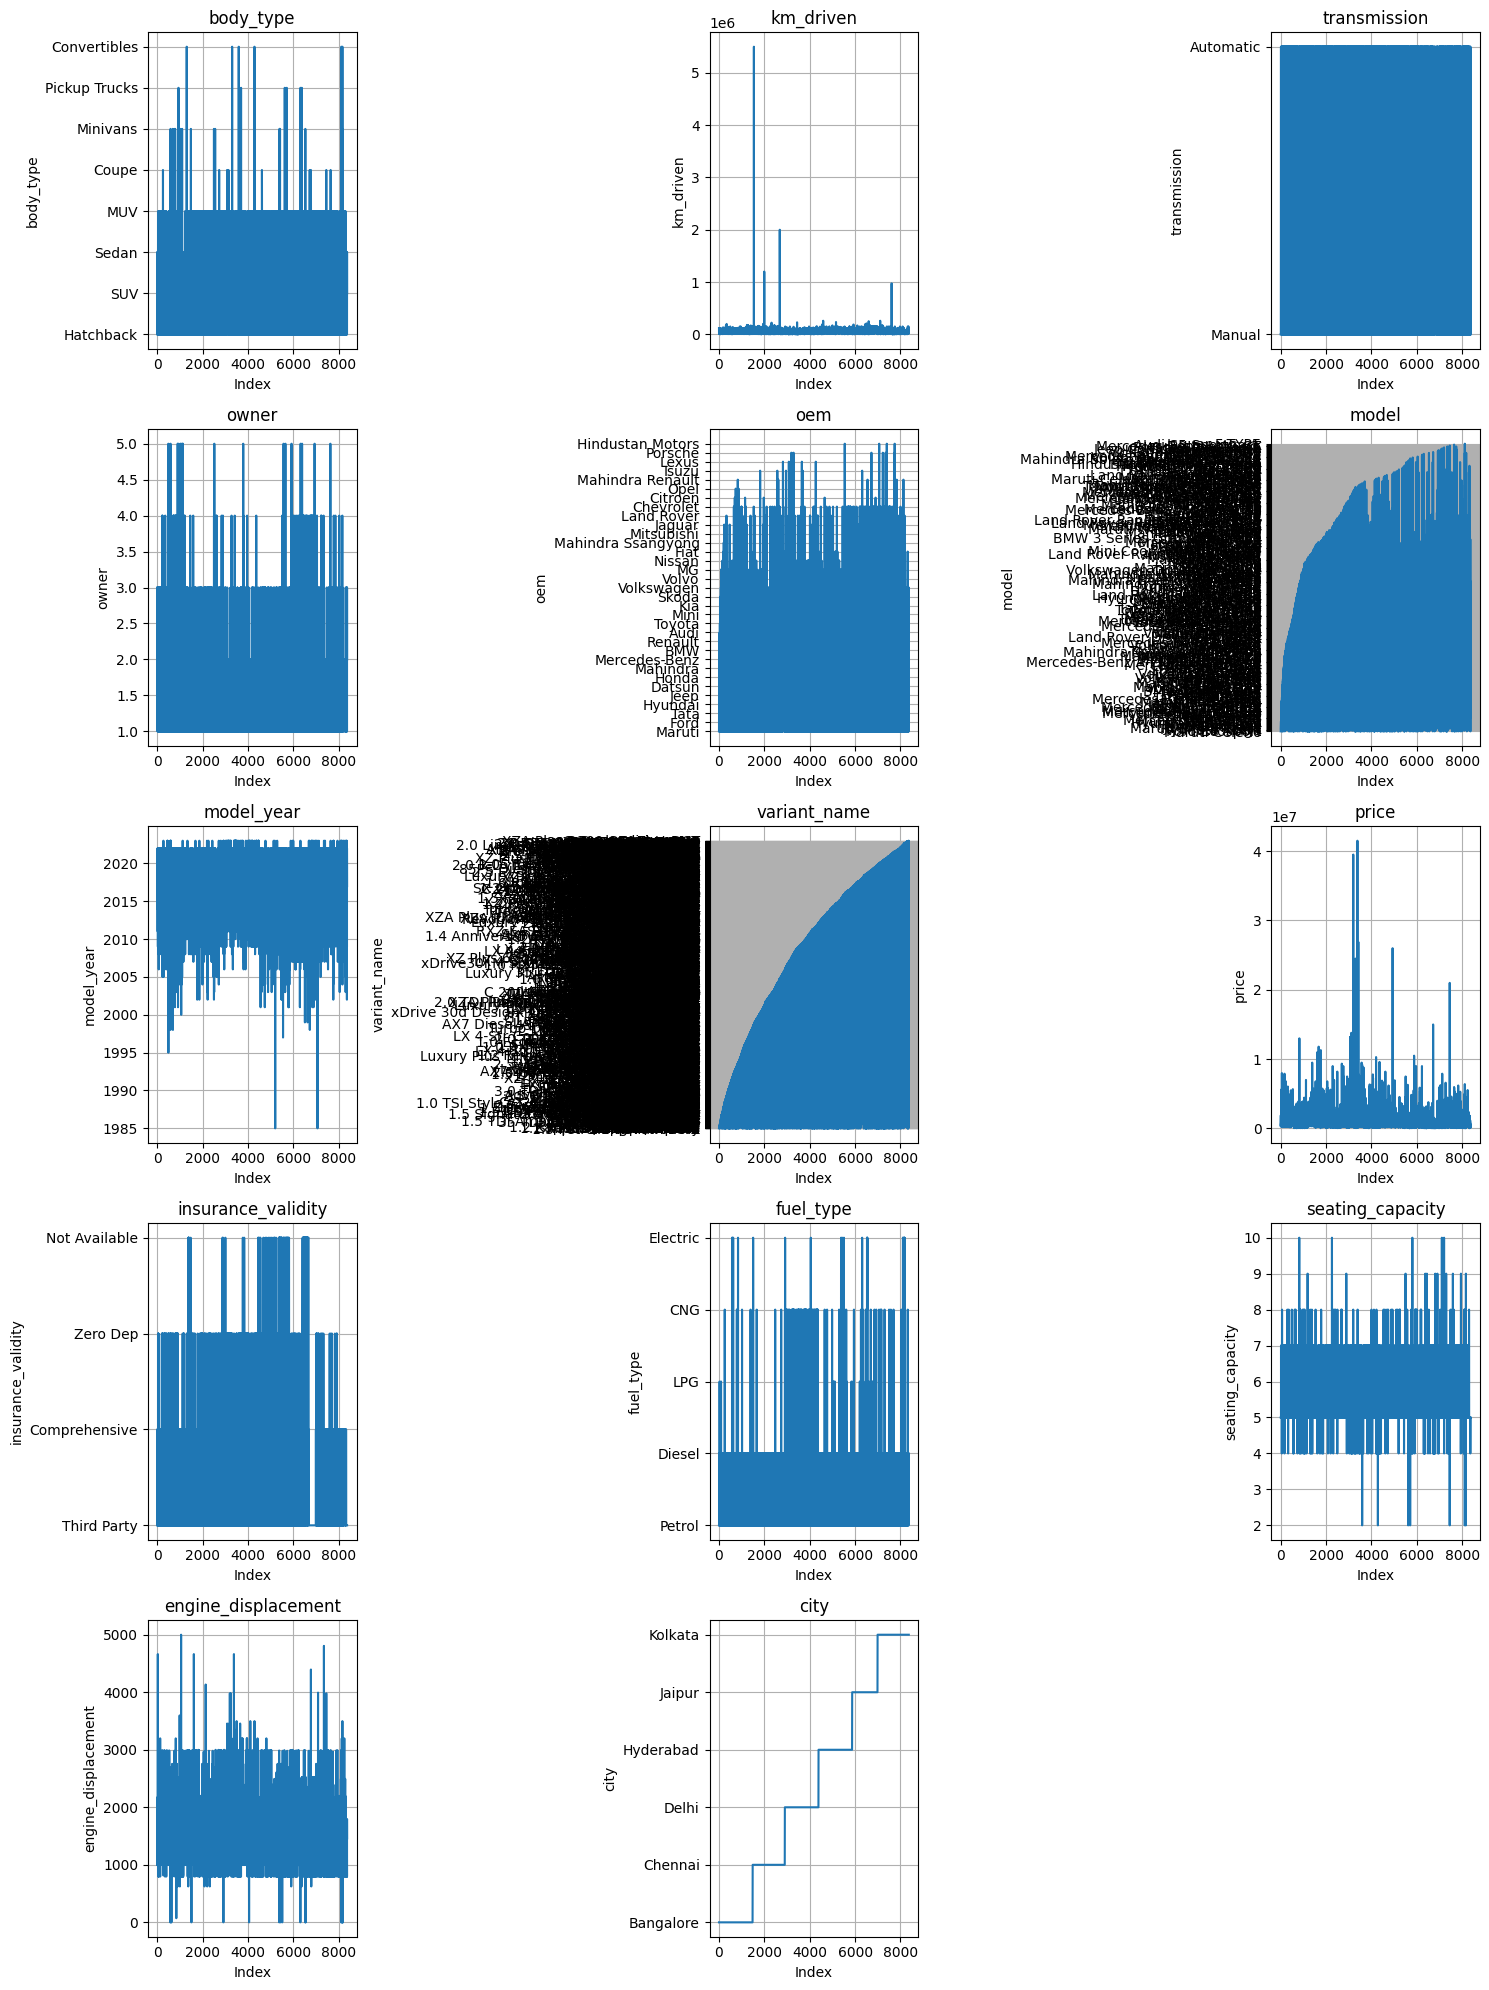

In [91]:
import matplotlib.pyplot as plt

# Set number of plots per row
plots_per_row = 3
num_columns = df_2.shape[1]
num_rows = (num_columns + plots_per_row - 1) // plots_per_row  # ceiling division

plt.figure(figsize=(plots_per_row * 5, num_rows * 4))

for i, column in enumerate(df_2.columns):
    plt.subplot(num_rows, plots_per_row, i + 1)
    plt.plot(df_2[column])
    plt.title(column)
    plt.xlabel('Index')
    plt.ylabel(column)
    plt.grid(True)

plt.tight_layout()
plt.show()

In [145]:
df_2 = df_2[df_2['body_type'] != 'Convertibles']
df_2 = df_2[df_2['body_type'] != 'Coupe']
df_2 = df_2[df_2['body_type'] != 'Pickup Trucks']

In [32]:
df_2['body_type'].value_counts()

body_type
Hatchback        3566
SUV              2225
Sedan            2173
MUV               352
Minivans           26
Coupe              10
Pickup Trucks       6
Convertibles        6
Name: count, dtype: int64

In [146]:
df_2 = df_2[df_2['km_driven'] != 0]

In [95]:
df_2[df_2['km_driven'] > 200000]

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
1538,MUV,800000,Manual,1,Toyota,Toyota Innova Crysta,2018,2.4 VX MT 8S BSIV,2150000,Comprehensive,Diesel,8,2393,Chennai
1539,Sedan,5500000,Automatic,1,Mercedes-Benz,Mercedes-Benz C-Class,2018,C 220 CDI Style,3600000,Comprehensive,Diesel,5,2143,Chennai
1946,Sedan,200300,Manual,2,Honda,Honda City,2014,1.5 V MT Exclusive,455000,Comprehensive,Petrol,5,1497,Chennai
1996,SUV,1200000,Manual,1,Mahindra,Mahindra Scorpio,2019,S5,1150000,Comprehensive,Diesel,7,2179,Chennai
2317,Sedan,222996,Manual,1,Honda,Honda Amaze,2014,VX Petrol,300000,Comprehensive,Petrol,5,1199,Chennai
2679,MUV,2000022,Manual,1,Toyota,Toyota Innova Crysta,2017,2.4 VX MT,1750000,Comprehensive,Diesel,7,2393,Chennai
3443,SUV,230000,Manual,1,Toyota,Toyota Fortuner,2013,4x2 Manual,969999,Comprehensive,Diesel,7,2982,Delhi
4594,SUV,260000,Manual,1,Toyota,Toyota Qualis,2003,FS F7,434999,Third Party,Diesel,8,2446,Hyderabad
5159,MUV,236000,Manual,1,Toyota,Toyota Innova,2008,2.5 G4 Diesel 8-seater,499000,Third Party,Diesel,8,2494,Hyderabad
6500,MUV,208978,Manual,1,Maruti,Maruti Ertiga,2013,VDI,450000,Not Available,Diesel,7,1248,Jaipur


In [96]:
df_2[df_2['km_driven'] > 270000]

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
1538,MUV,800000,Manual,1,Toyota,Toyota Innova Crysta,2018,2.4 VX MT 8S BSIV,2150000,Comprehensive,Diesel,8,2393,Chennai
1539,Sedan,5500000,Automatic,1,Mercedes-Benz,Mercedes-Benz C-Class,2018,C 220 CDI Style,3600000,Comprehensive,Diesel,5,2143,Chennai
1996,SUV,1200000,Manual,1,Mahindra,Mahindra Scorpio,2019,S5,1150000,Comprehensive,Diesel,7,2179,Chennai
2679,MUV,2000022,Manual,1,Toyota,Toyota Innova Crysta,2017,2.4 VX MT,1750000,Comprehensive,Diesel,7,2393,Chennai
7610,SUV,975000,Manual,1,Kia,Kia Sonet,2021,HTX Turbo iMT BSVI,975000,Third Party,Petrol,5,998,Kolkata


In [147]:
df_2 = df_2[df_2['km_driven'] < 200000]

In [148]:
df_2 = df_2[(df_2['seating_capacity'] >= 4) & (df_2['seating_capacity'] <= 8)]

In [99]:
df_2.groupby('model_year').size()

model_year
1985      2
1995      2
1997      1
1998      3
1999      2
2000      1
2001      8
2002     10
2003     12
2004     25
2005     18
2006     43
2007     54
2008     84
2009    142
2010    251
2011    271
2012    337
2013    396
2014    582
2015    601
2016    811
2017    940
2018    973
2019    786
2020    608
2021    682
2022    562
2023    102
dtype: int64

In [149]:
df_2 = df_2[df_2['model_year'] > 2005]

In [101]:
df_2.groupby('model_year').size()

model_year
2006     43
2007     54
2008     84
2009    142
2010    251
2011    271
2012    337
2013    396
2014    582
2015    601
2016    811
2017    940
2018    973
2019    786
2020    608
2021    682
2022    562
2023    102
dtype: int64

In [97]:
df_2.shape

(8225, 15)

In [103]:
df_2[(df_2['engine_displacement'] == 0)].shape

(26, 14)

In [104]:
df_2[(df_2['transmission'] == 'Automatic') & (df_2['fuel_type'] == 'Electric')].shape

(28, 14)

In [105]:
df_2[(df_2['engine_displacement'] == 0) & (df_2['fuel_type'] == 'Electric')].shape

(26, 14)

In [106]:
df_2[(df_2['fuel_type'] == 'Electric') &
     (df_2['transmission'] == 'Automatic') &
     (df_2['engine_displacement'] != 0)]

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city
574,Hatchback,20000,Automatic,1,Mahindra,Mahindra e2o Plus,2017,P6,550000,Third Party,Electric,4,72,Bangalore
839,Hatchback,20000,Automatic,2,Mahindra,Mahindra e2o Plus,2017,P8,459999,Third Party,Electric,4,72,Bangalore


In [150]:
df_2.loc[
    (df_2['fuel_type'] == 'Electric') &
    (df_2['transmission'] == 'Automatic') &
    (df_2['engine_displacement'] != 0),
    'engine_displacement'
] = 0

In [108]:
df_2[(df_2['fuel_type'] == 'Electric') &
     (df_2['transmission'] == 'Automatic') &
     (df_2['engine_displacement'] != 0)]

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city


In [109]:
df_2[(df_2['engine_displacement'] > 3500)].shape

(12, 14)

In [151]:
df_2 = df_2[(df_2['engine_displacement'] <= 3500)]

In [152]:
df_2.shape

(8213, 15)

In [112]:
df_2[(df_2['price'] > 15000000)].shape

(4, 14)

In [153]:
df_2 = df_2[(df_2['price'] < 15000000)]

In [102]:
df_2.shape

(8209, 15)

In [154]:
oem_counts = df_2['oem'].value_counts()

valid_oems = oem_counts[oem_counts >= 10].index

df_2 = df_2[df_2['oem'].isin(valid_oems)]

In [155]:
model_counts = df_2['model'].value_counts()

valid_oems = model_counts[model_counts >= 3].index

df_2 = df_2[df_2['model'].isin(valid_oems)]

In [105]:
df_2.shape

(8091, 15)

In [118]:
df_2.describe()

,km_driven,owner,model_year,price,seating_capacity,engine_displacement
count,8091.00,8091.00,8091.00,8091.00,8091.00,8091.00
mean,57317.93,1.35,2016.66,907586.68,5.20,1408.10
std,33492.26,0.62,3.62,1044594.42,0.62,444.48
min,200.00,1.00,2006.00,28000.00,4.00,0.00
25%,30000.00,1.00,2014.00,400000.00,5.00,1197.00
50%,53165.00,1.00,2017.00,605000.00,5.00,1199.00
75%,79805.50,2.00,2019.00,949000.00,5.00,1498.00
max,199000.00,5.00,2023.00,13799999.00,8.00,3498.00


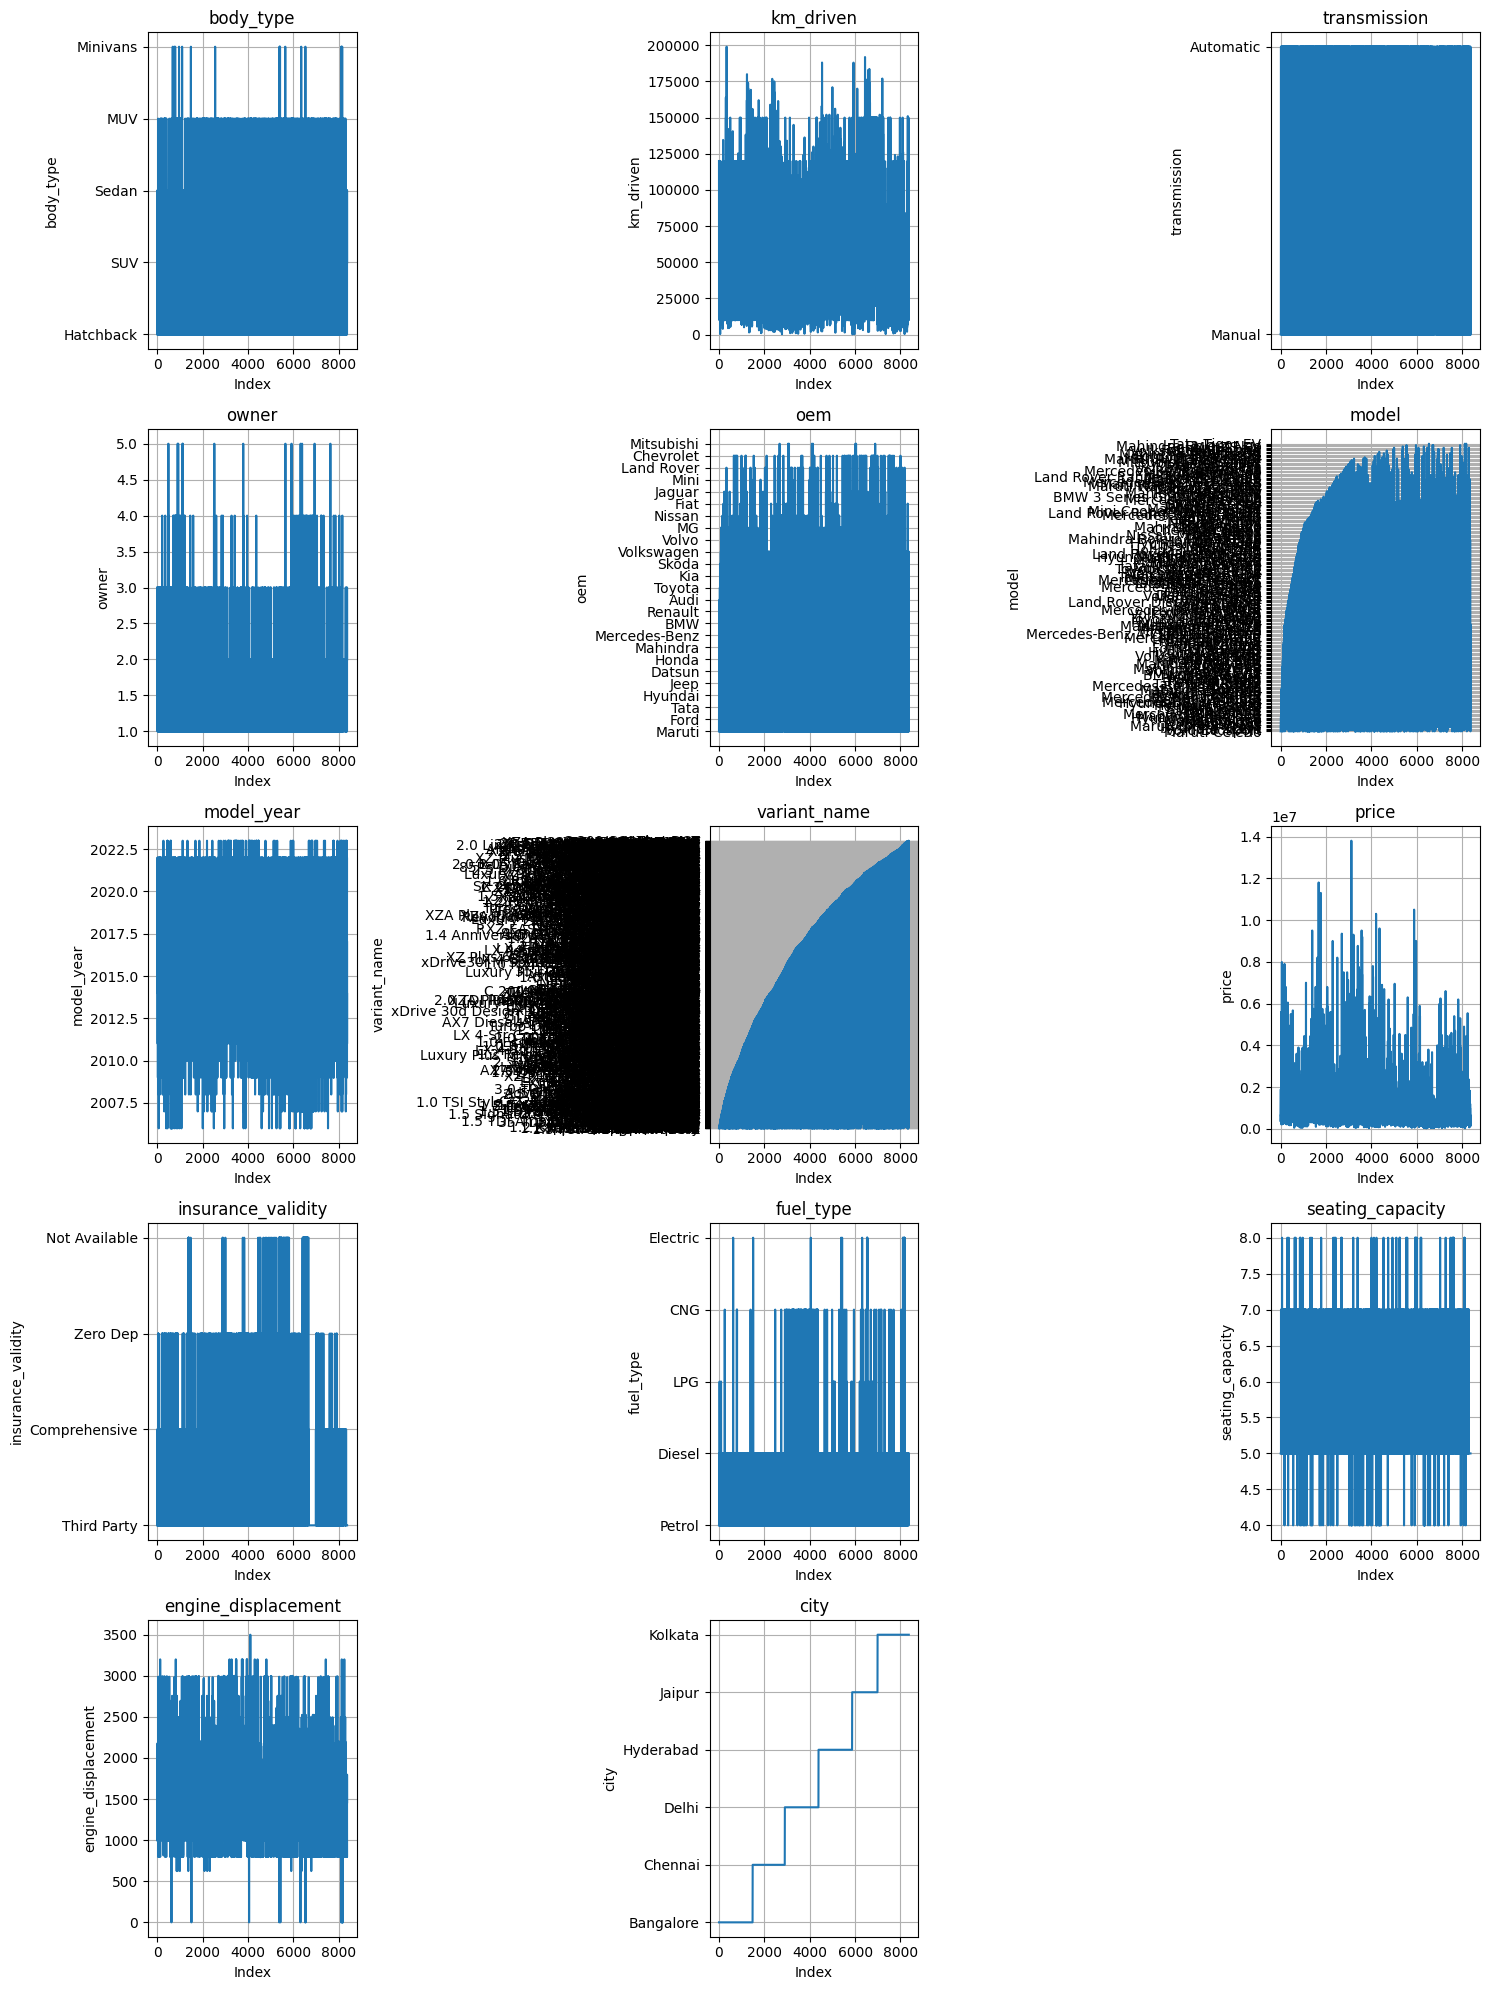

In [119]:
import matplotlib.pyplot as plt

# Set number of plots per row
plots_per_row = 3
num_columns = df_2.shape[1]
num_rows = (num_columns + plots_per_row - 1) // plots_per_row  # ceiling division

plt.figure(figsize=(plots_per_row * 5, num_rows * 4))

for i, column in enumerate(df_2.columns):
    plt.subplot(num_rows, plots_per_row, i + 1)
    plt.plot(df_2[column])
    plt.title(column)
    plt.xlabel('Index')
    plt.ylabel(column)
    plt.grid(True)

plt.tight_layout()
plt.show()

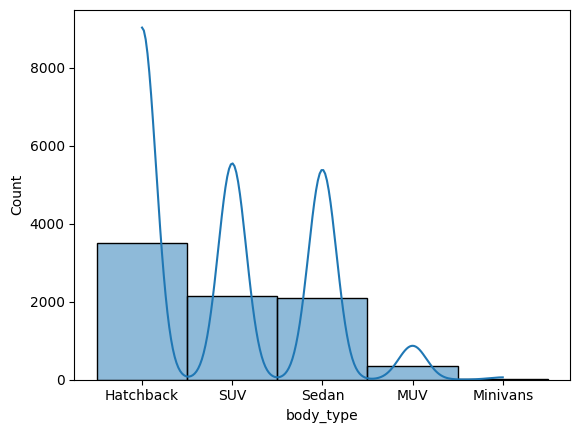

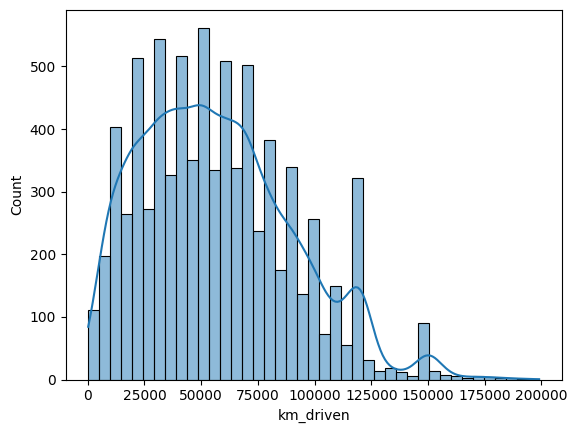

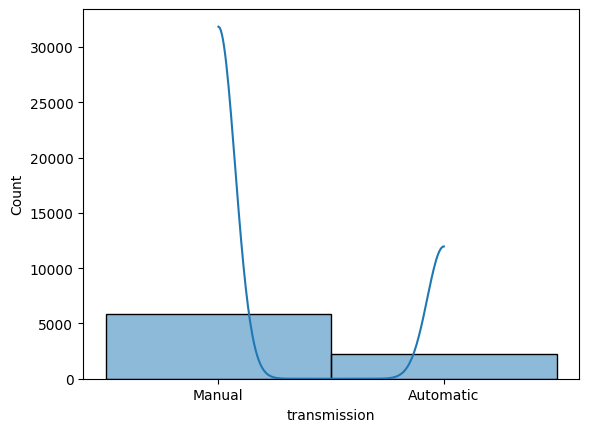

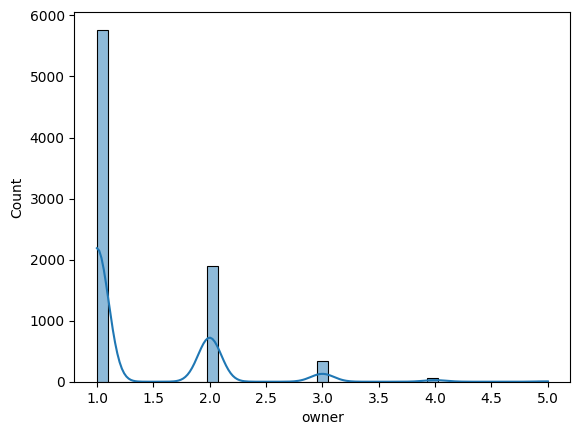

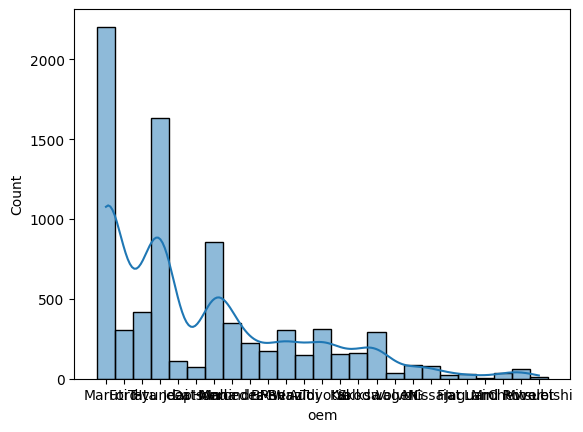

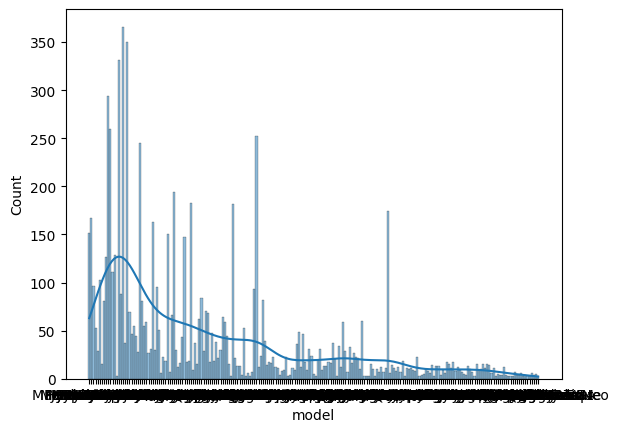

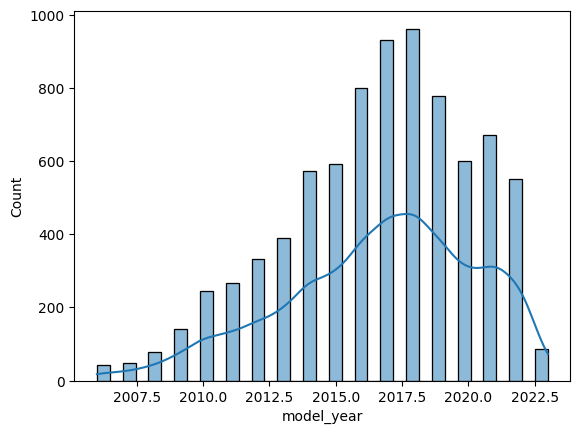

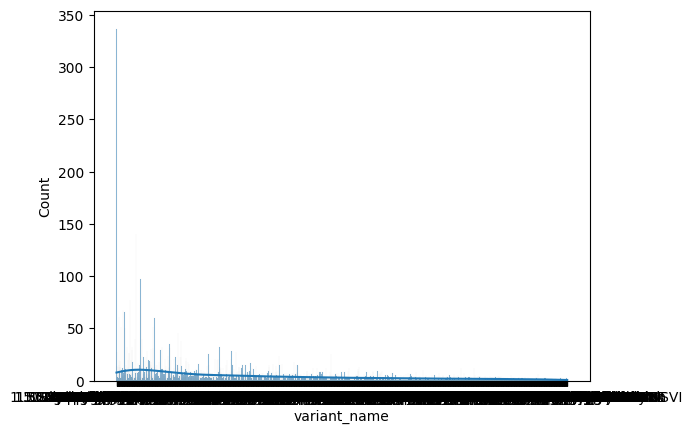

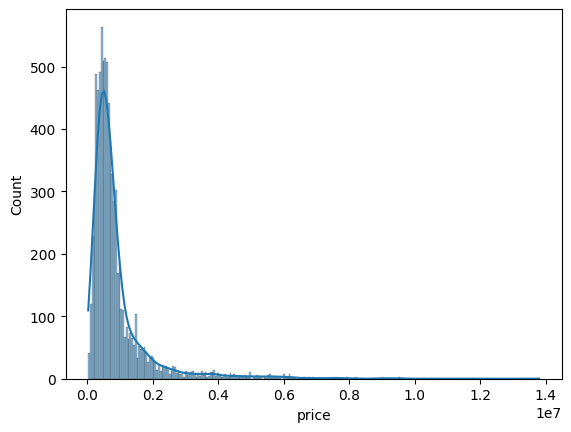

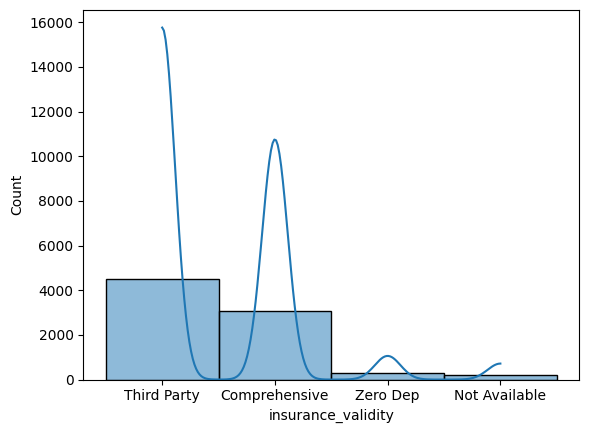

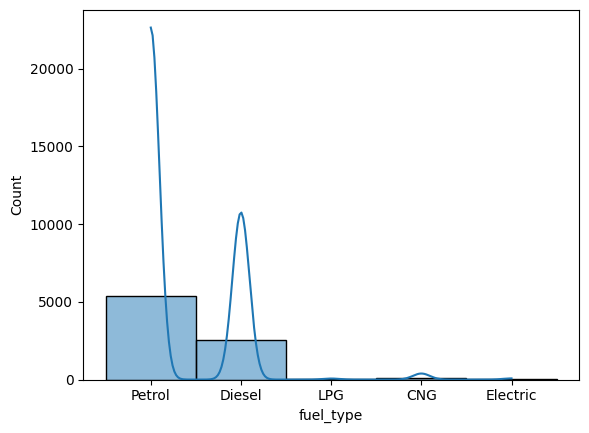

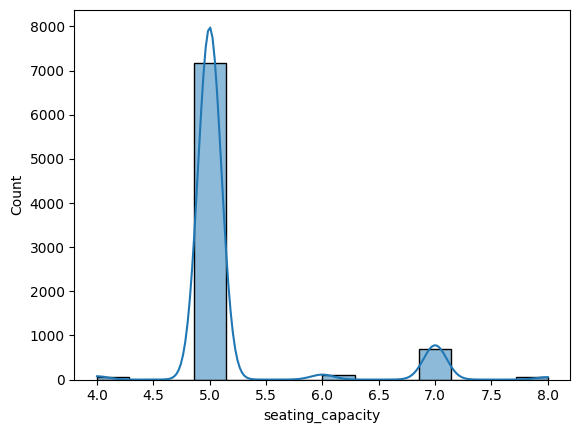

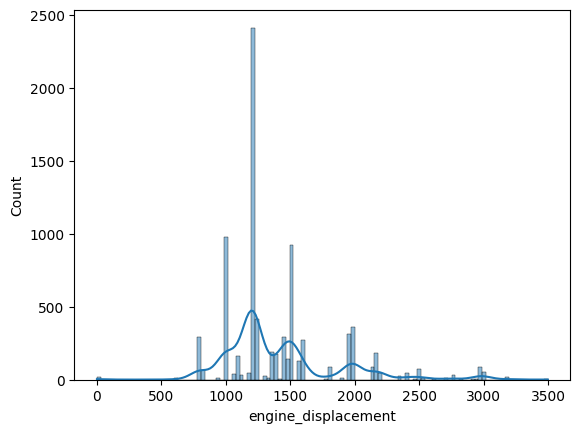

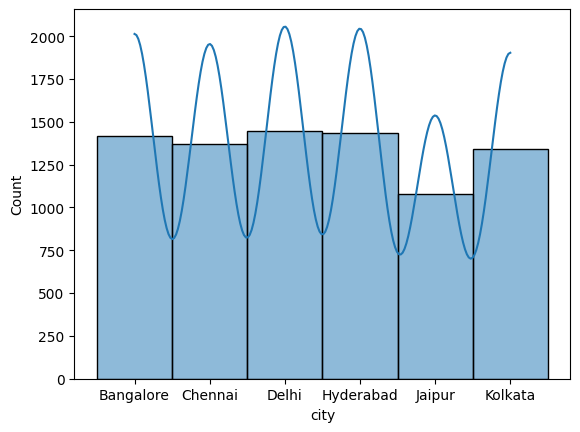

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

for column in df_2.columns:
    sns.histplot(df_2[column], kde=True)
    plt.show()

In [46]:
df_2.shape

(8091, 14)

##### Feature Engineering

In [156]:
df3 = df_2.copy()

In [123]:
print(df3['variant_name'].value_counts().to_string())

variant_name
VXI                                           337
LXI                                           140
Sportz                                         97
VDI                                            77
Magna                                          77
VXI BS IV                                      68
Sportz 1.2                                     66
1.2 Delta                                      61
ZXI                                            60
i VTEC V                                       51
i-VTEC VX                                      51
1.2 Zeta                                       50
VXI BSVI                                       46
S MT                                           40
Asta 1.2                                       40
Zeta                                           38
Asta                                           35
i VTEC CVT VX                                  32
VDi                                            32
V MT                                 

Variants with single count

In [124]:
variants_counts = df3['variant_name'].value_counts()
single_variants = variants_counts[(variants_counts == 1)].index
filtered_df = df3[df3['variant_name'].isin(single_variants)]

filtered_df.shape

(828, 14)

Models with less than 10 counts

In [125]:
model_counts = df3['model'].value_counts()
few_models = model_counts[(model_counts < 10)].index
filtered_df = df3[df3['model'].isin(few_models)]

filtered_df.shape

(378, 14)

In [126]:
model_counts = df3['model'].value_counts()
few_models = model_counts[(model_counts < 10)].index
filtered_df = df3[df3['model'].isin(few_models)]

filtered_df.shape                                                                              # 378
filtered_df[(filtered_df['price'] < 500000)].shape                                                 # 102
filtered_df[(filtered_df['price'] > 500000) & (filtered_df['price'] < 2000000)].shape             # 141
filtered_df[(filtered_df['price'] > 2000000)].shape                                                 # 132

(132, 14)

In [157]:
## Assigning model_variant column
# High - Mid - Low Variant -- based on price  --- for MODELS with count less than 10
# model + variant_name                        --- for MODELS with >= 10 counts


def generate_model_variant(row, rare_models):
    if row['model'] in rare_models:
        if row['price'] < 500000:
            return 'Other | Low Variant'
        elif 500000 <= row['price'] < 2000000:
            return 'Other | Mid Variant'
        else:
            return 'Other | High Variant'
    else:
        return f"{row['model']} | {row['variant_name']}"
    

model_counts = df3['model'].value_counts()
rare_models = model_counts[model_counts < 10].index.tolist()

df3['model_variant'] = df3.apply(lambda row: generate_model_variant(row, rare_models), axis=1)

In [128]:
model_variant_counts = df3['model_variant'].value_counts()
single_model_variant_points = model_variant_counts[(model_variant_counts == 1)].index
filtered_df = df3[df3['model_variant'].isin(single_model_variant_points)]

filtered_df.shape

(839, 15)

In [129]:
print(df3['model_variant'].value_counts().to_string())

model_variant
Other | Mid Variant                                                  143
Other | High Variant                                                 133
Maruti Swift | VXI                                                   123
Other | Low Variant                                                  102
Maruti Alto 800 | LXI                                                 88
Maruti Wagon R | VXI BS IV                                            68
Maruti Baleno | 1.2 Delta                                             61
Honda City | i VTEC V                                                 51
Maruti Swift Dzire | VXI                                              50
Maruti Baleno | 1.2 Zeta                                              50
Maruti Alto K10 | VXI                                                 49
Hyundai i20 | Sportz 1.2                                              48
Hyundai i10 | Magna                                                   45
Honda WR-V | i-VTEC VX               

## Assigning single model_variant data points 

If it's a rare variant - But the base model has > 1 entry --> Use a generic "Model | Variant" tag
If the model is rare, fallback to "OEM | Other"
If it's not a rare variant, keep it unchanged

In [158]:
## Assigning single model_variant data points with model itself if it has more than 1 count in model

model_variant_counts = df3['model_variant'].value_counts()
rare_model_variant = model_variant_counts[model_variant_counts == 1].index

model_counts = df3['model'].value_counts()

def updated_variant(row):
    if row['model_variant'] in rare_model_variant:
        if model_counts[row['model']] > 1:
            return f"{row['model']} | Variant"
        else:
            return f"{row['oem']} | Other"  
    else:
        return row['model_variant']

df3['model_variant'] = df3.apply(updated_variant, axis=1)

In [131]:
print(df3['model_variant'].value_counts().to_string())

model_variant
Other | Mid Variant                                                  143
Other | High Variant                                                 133
Maruti Swift | VXI                                                   123
Other | Low Variant                                                  102
Maruti Alto 800 | LXI                                                 88
Maruti Wagon R | VXI BS IV                                            68
Maruti Baleno | 1.2 Delta                                             61
Honda City | i VTEC V                                                 51
Maruti Swift Dzire | VXI                                              50
Maruti Baleno | 1.2 Zeta                                              50
Maruti Alto K10 | VXI                                                 49
Hyundai i20 | Sportz 1.2                                              48
Hyundai i10 | Magna                                                   45
Honda WR-V | i-VTEC VX               

In [132]:
df3[df3['model'] == 'Hyundai Accent']

,body_type,km_driven,transmission,owner,oem,model,model_year,variant_name,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city,model_variant
254,Sedan,70000,Manual,1,Hyundai,Hyundai Accent,2010,Executive CNG,220000,Third Party,CNG,5,1495,Bangalore,Hyundai Accent | Variant
1073,Sedan,60000,Manual,1,Hyundai,Hyundai Accent,2009,GLX,260000,Third Party,Petrol,5,1495,Bangalore,Hyundai Accent | GLX
1939,Sedan,80000,Manual,2,Hyundai,Hyundai Accent,2012,Executive,250000,Third Party,Petrol,5,1495,Chennai,Hyundai Accent | Executive
3412,Sedan,53000,Manual,2,Hyundai,Hyundai Accent,2010,GLX,80000,Third Party,Petrol,5,1495,Delhi,Hyundai Accent | GLX
3721,Sedan,80000,Manual,1,Hyundai,Hyundai Accent,2009,Executive,100000,Third Party,Petrol,5,1495,Delhi,Hyundai Accent | Executive
5920,Sedan,100000,Manual,2,Hyundai,Hyundai Accent,2011,Executive LPG,210000,Third Party,LPG,5,1495,Jaipur,Hyundai Accent | Executive LPG
6496,Sedan,94970,Manual,2,Hyundai,Hyundai Accent,2006,GLE,142000,Not Available,Petrol,5,1495,Jaipur,Hyundai Accent | GLE
6732,Sedan,60000,Manual,1,Hyundai,Hyundai Accent,2008,GLE,100000,Third Party,Petrol,5,1495,Jaipur,Hyundai Accent | GLE
6772,Sedan,150000,Manual,2,Hyundai,Hyundai Accent,2009,Executive LPG,100000,Third Party,LPG,5,1495,Jaipur,Hyundai Accent | Executive LPG
6946,Sedan,70000,Manual,1,Hyundai,Hyundai Accent,2011,Executive,300000,Third Party,Petrol,5,1495,Jaipur,Hyundai Accent | Executive


Removing all the model_variants which has only one data point

In [133]:
df3.shape

(8091, 15)

In [159]:
variant_counts = df3['model_variant'].value_counts()
df3 = df3[df3['model_variant'].isin(variant_counts[variant_counts > 1].index)]
df3.shape

(8082, 16)

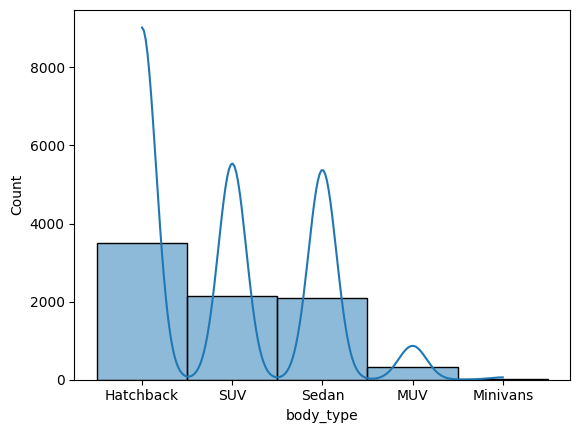

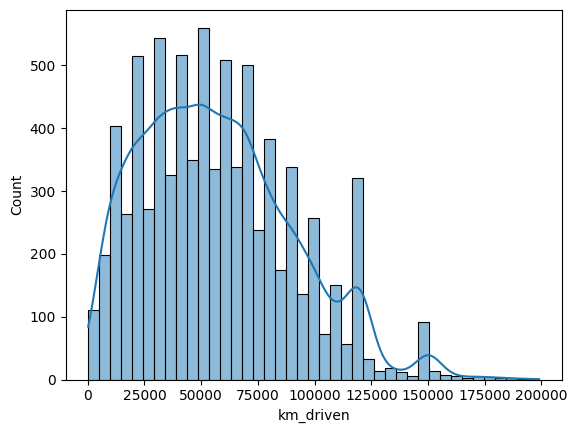

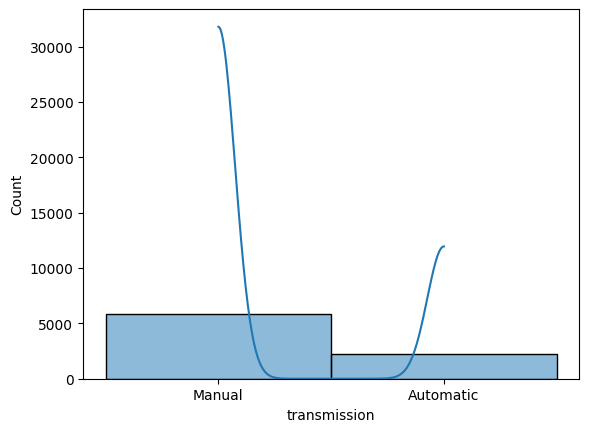

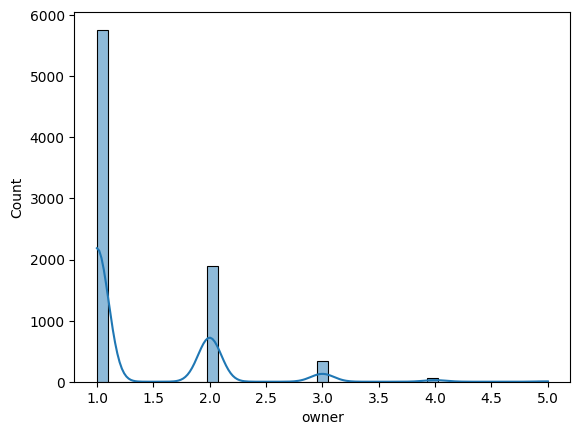

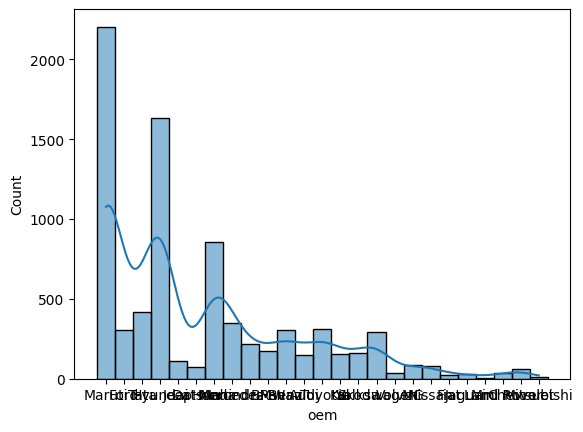

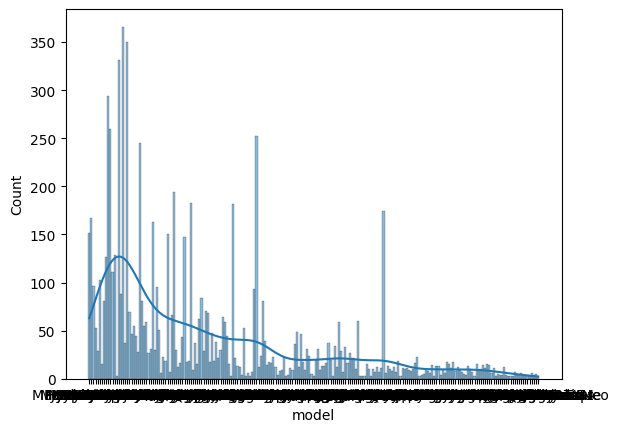

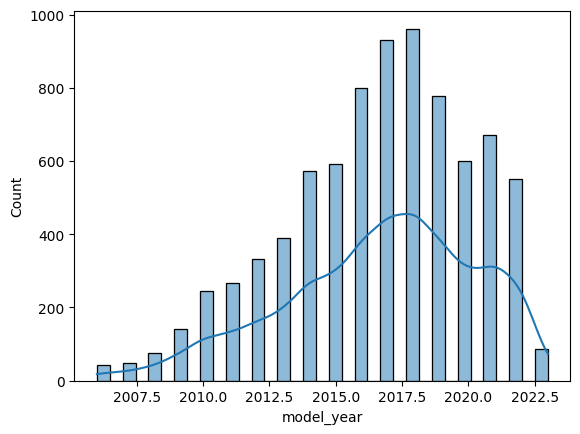

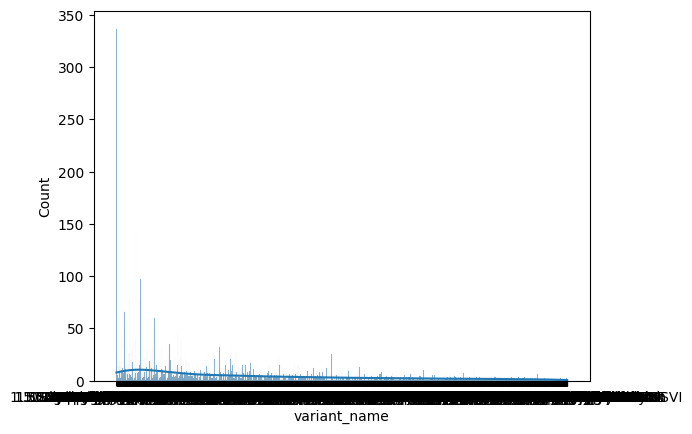

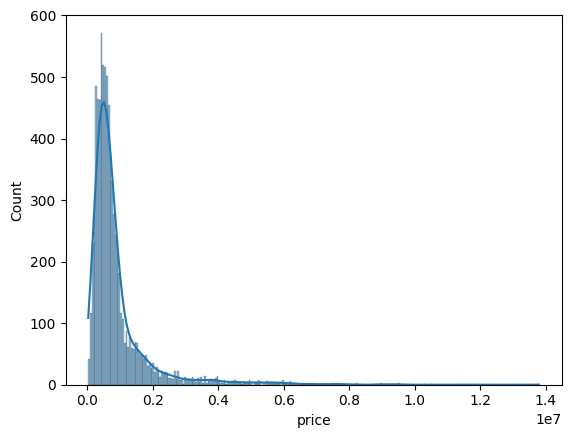

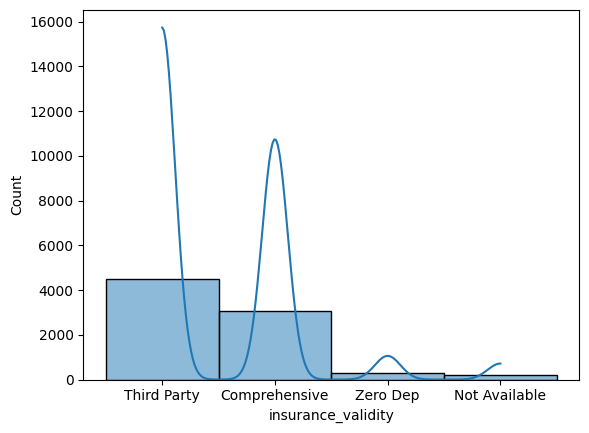

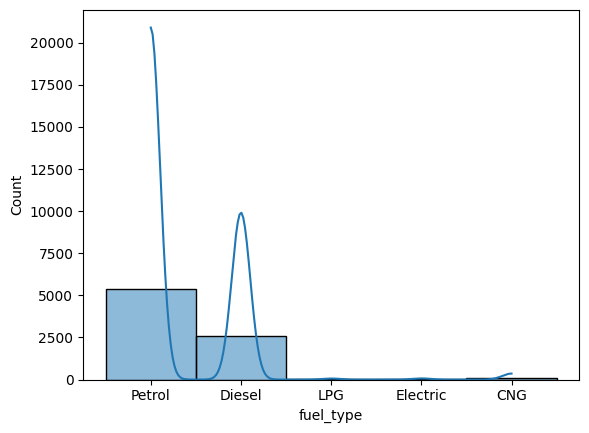

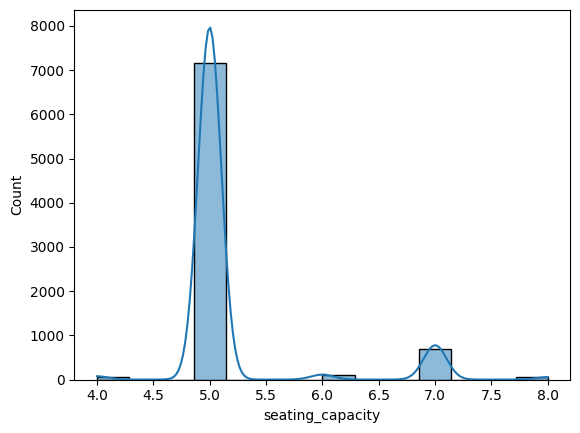

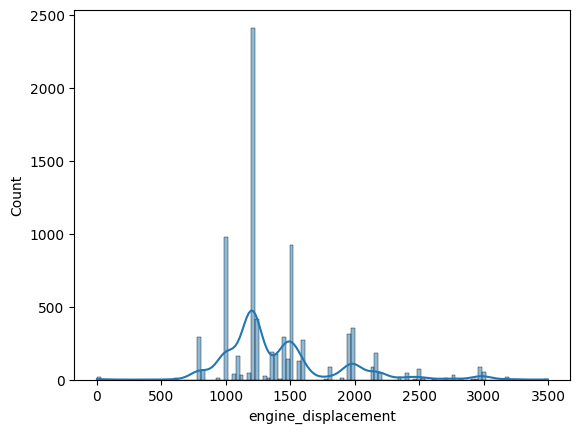

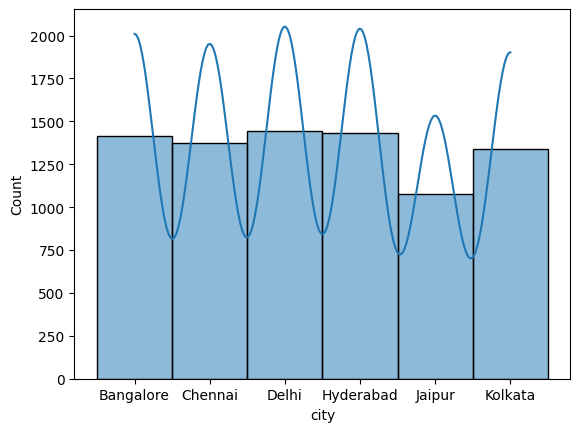

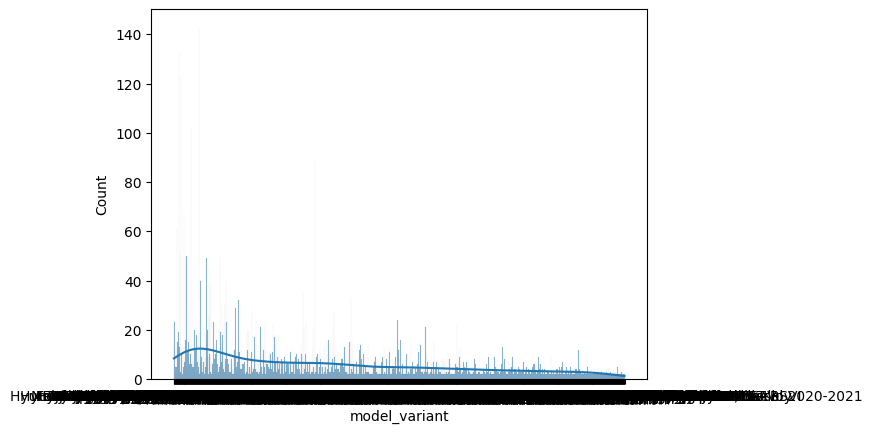

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

for column in df3.columns:
    sns.histplot(df3[column], kde=True)
    plt.show()

In [160]:
df3.columns

Index(['body_type', 'km_driven', 'transmission', 'owner', 'oem', 'model',
       'model_year', 'variant_name', 'price', 'insurance_validity',
       'fuel_type', 'seating_capacity', 'engine_displacement', 'city',
       'car_links', 'model_variant'],
      dtype='object')

In [161]:
df3.shape

(8082, 16)

In [162]:
df3.to_csv('reference_data.csv', index=False)

In [ ]:
df3[['oem', 'model', 'variant_name', 'model_variant', 'price']].to_csv('reference_data.csv', index=False)

In [55]:
df3.to_excel('for_corr.xlsx', index=False)

In [112]:
df3.drop(['oem', 'model', 'variant_name', 'car_links'], axis=1, inplace=True)

In [113]:
df3.shape

(8082, 12)

In [141]:
df3.head()

,body_type,km_driven,transmission,owner,model_year,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city,model_variant
0,Hatchback,120000,Manual,3,2015,400000,Third Party,Petrol,5,998,Bangalore,Maruti Celerio | VXI
1,SUV,32706,Manual,2,2018,811000,Comprehensive,Petrol,5,1497,Bangalore,Ford Ecosport | 1.5 Petrol Titanium BSIV
2,Hatchback,11949,Manual,1,2018,585000,Comprehensive,Petrol,5,1199,Bangalore,Tata Tiago | 1.2 Revotron XZ
3,Sedan,17794,Manual,1,2014,462000,Comprehensive,Petrol,5,1197,Bangalore,Hyundai Xcent | 1.2 Kappa S Option
4,SUV,60000,Manual,1,2015,790000,Third Party,Diesel,5,1248,Bangalore,Maruti SX4 S Cross | DDiS 200 Zeta


In [58]:
df3.to_excel('before_encoding.xlsx', index=False)

##### Feature importance with Label Encoding

In [143]:
import pandas as pd

df = pd.read_excel('before_encoding.xlsx')

df.head()

,body_type,km_driven,transmission,owner,model_year,price,insurance_validity,fuel_type,seating_capacity,engine_displacement,city,model_variant
0,Hatchback,120000,Manual,3,2015,400000,Third Party,Petrol,5,998,Bangalore,Maruti Celerio | VXI
1,SUV,32706,Manual,2,2018,811000,Comprehensive,Petrol,5,1497,Bangalore,Ford Ecosport | 1.5 Petrol Titanium BSIV
2,Hatchback,11949,Manual,1,2018,585000,Comprehensive,Petrol,5,1199,Bangalore,Tata Tiago | 1.2 Revotron XZ
3,Sedan,17794,Manual,1,2014,462000,Comprehensive,Petrol,5,1197,Bangalore,Hyundai Xcent | 1.2 Kappa S Option
4,SUV,60000,Manual,1,2015,790000,Third Party,Diesel,5,1248,Bangalore,Maruti SX4 S Cross | DDiS 200 Zeta


In [144]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['body_type', 'transmission', 'insurance_validity', 'fuel_type', 'city', 'model_variant']
numerical_cols = ['km_driven', 'owner', 'model_year', 'price', 'seating_capacity', 'engine_displacement']

# Label Encoding
label_encoded_df = df[categorical_cols].copy()
for col in categorical_cols:
    le = LabelEncoder()
    label_encoded_df[col] = le.fit_transform(label_encoded_df[col])

label_encoded_df = label_encoded_df.astype(int)

# Selecting numerical columns
numerical_df = df[numerical_cols].copy()

# Combine both
final_df = pd.concat([label_encoded_df, numerical_df], axis=1)
final_df


,body_type,transmission,insurance_validity,fuel_type,city,model_variant,km_driven,owner,model_year,price,seating_capacity,engine_displacement
0,0,1,2,4,0,755,120000,3,2015,400000,5,998
1,3,1,0,4,0,122,32706,2,2018,811000,5,1497
2,0,1,0,4,0,1207,11949,1,2018,585000,5,1199
3,4,1,0,4,0,449,17794,1,2014,462000,5,1197
4,3,1,2,1,0,862,60000,1,2015,790000,5,1248
...,...,...,...,...,...,...,...,...,...,...,...,...
8077,0,1,2,4,5,772,10000,1,2022,509999,5,998
8078,0,1,2,4,5,698,120000,1,2014,180000,5,796
8079,4,0,2,4,5,992,50000,3,2011,550000,5,1796
8080,0,1,2,4,5,851,40000,1,2012,140000,5,1197


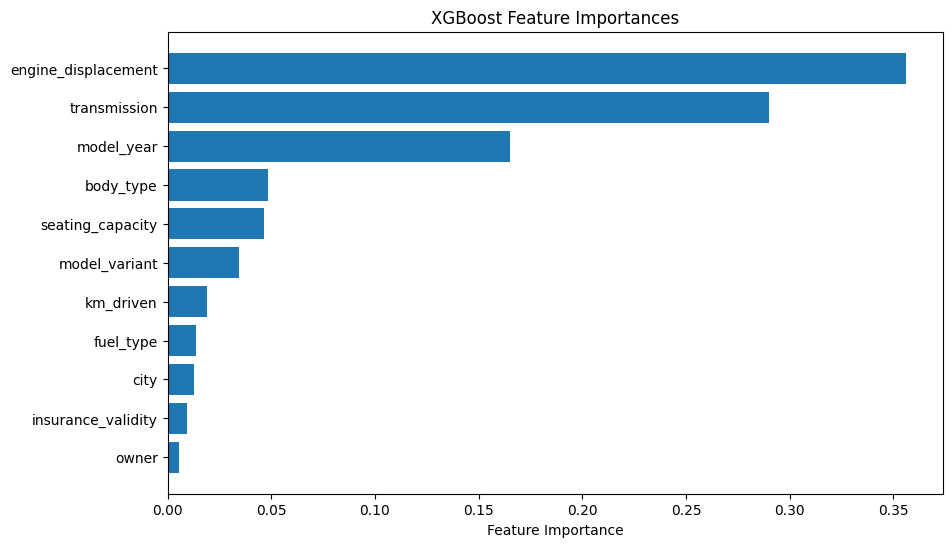

In [145]:
from xgboost import XGBRegressor
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define your features and target
X = final_df.drop('price', axis=1)  # assuming 'price' is your target column
y = final_df['price']

# 2. Fit XGBoost model
model = XGBRegressor()
model.fit(X, y)
# 3. Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# 4. Create and plot feature importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 5. Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importances')
plt.gca().invert_yaxis()
plt.show()


In [146]:
from xgboost import XGBRegressor
import pandas as pd

X = final_df.drop('price', axis=1)  # Features
y = final_df['price']               # Target

model = XGBRegressor()
model.fit(X, y)

importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)


                Feature  Importance
10  engine_displacement        0.36
1          transmission        0.29
8            model_year        0.17
0             body_type        0.05
9      seating_capacity        0.05
5         model_variant        0.03
6             km_driven        0.02
3             fuel_type        0.01
4                  city        0.01
2    insurance_validity        0.01
7                 owner        0.01


In [147]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR  
from sklearn.metrics import mean_squared_error


models = [LinearRegression(), Ridge(), XGBRegressor(), DecisionTreeRegressor(), RandomForestRegressor(), SVR()]

for model in models:
    model_name = model.__class__.__name__
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    
    print(f"Model: {model_name}")
    print(f"Train Score: {train_score:.4f}")
    print(f"Test Score: {test_score:.4f}")
    print(f"MSE Train: {mse_train:.4f}")
    print(f"MSE Test: {mse_test:.4f}")
    print('______________________')

Model: LinearRegression
Train Score: 0.5784
Test Score: 0.5758
MSE Train: 474974806388.2450
MSE Test: 425482686816.7640
______________________
Model: Ridge
Train Score: 0.5784
Test Score: 0.5758
MSE Train: 474974853362.5356
MSE Test: 425485691325.3143
______________________
Model: XGBRegressor
Train Score: 0.9946
Test Score: 0.9092
MSE Train: 6046781440.0000
MSE Test: 91064631296.0000
______________________
Model: DecisionTreeRegressor
Train Score: 0.9997
Test Score: 0.7999
MSE Train: 335780775.4406
MSE Test: 200688292676.2974
______________________
Model: RandomForestRegressor
Train Score: 0.9874
Test Score: 0.8930
MSE Train: 14229063198.8076
MSE Test: 107317333646.5812
______________________
Model: SVR
Train Score: -0.0817
Test Score: -0.0991
MSE Train: 1218681480348.9067
MSE Test: 1102552794925.1951
______________________


##### Encoding & Scaling

In [148]:
import pandas as pd

df4 = pd.read_excel('before_encoding.xlsx')

df4.shape

(8082, 12)

In [149]:
# df3.isna().sum()

In [150]:
# df4 = df3.copy()
# print(df4.shape)
# print(df4.columns)

In [151]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

categorical_cols = ['body_type', 'transmission', 'insurance_validity', 'fuel_type', 'city', 'model_variant']
numerical_cols = ['km_driven', 'owner', 'model_year', 'price', 'seating_capacity', 'engine_displacement']
cols_to_normalize = ['km_driven', 'engine_displacement', 'model_year', 'seating_capacity', 'owner']


## Encoding the Categorical Columns
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoded_array = encoder.fit_transform(df4[categorical_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols))
encoded_df = encoded_df.astype(int)

## Scaling the Numerical Columns 
scaler = MinMaxScaler()
scaled_numerical = pd.DataFrame(scaler.fit_transform(df4[cols_to_normalize]), columns=cols_to_normalize)

# ## Scaling the Target Column 
target_column = 'price'
target_scaler = MinMaxScaler()
df4[target_column] = target_scaler.fit_transform(df4[[target_column]])


## Combining the data frames
df4 = pd.concat([scaled_numerical, encoded_df, df4[target_column]], axis=1)

print(df4.shape)
df4.head()


(8082, 1388)


,km_driven,engine_displacement,model_year,seating_capacity,owner,body_type_MUV,body_type_Minivans,body_type_SUV,body_type_Sedan,transmission_Manual,insurance_validity_Not Available,insurance_validity_Third Party,insurance_validity_Zero Dep,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,model_variant_Audi A3 | 35 TDI Technology,model_variant_Audi A3 | 35 TFSI Premium Plus,model_variant_Audi A3 | Variant,model_variant_Audi A4 | 1.8 TFSI,model_variant_Audi A4 | 2.0 TDI,model_variant_Audi A4 | 2.0 TDI Premium Plus,model_variant_Audi A4 | 2.0 TDI Premium Sport Limited Edition,model_variant_Audi A4 | 35 TDI Premium,model_variant_Audi A4 | 35 TDI Premium Plus,model_variant_Audi A4 | New 2.0 TDI Multitronic,model_variant_Audi A4 | Technology,model_variant_Audi A4 | Variant,model_variant_Audi A6 | 2.0 TDI,model_variant_Audi A6 | 2.0 TDI Premium Plus,model_variant_Audi A6 | 2.0 TDI Technology,model_variant_Audi A6 | 3.0 TDI Quattro Premium Plus,model_variant_Audi A6 | 35 TDI,model_variant_Audi A6 | 35 TDI Premium,model_variant_Audi A6 | 35 TDI Technology,model_variant_Audi A6 | 35 TFSI,model_variant_Audi A6 | 35 TFSI Matrix,model_variant_Audi A6 | Variant,model_variant_Audi Q3 | 2.0 TDI,model_variant_Audi Q3 | 2.0 TDI Quattro Premium Plus,model_variant_Audi Q3 | 30 TDI,model_variant_Audi Q3 | 30 TFSI Premium FWD,model_variant_Audi Q3 | 35 TDI Quattro Premium,model_variant_Audi Q3 | 35 TDI Quattro Premium Plus,model_variant_Audi Q3 | Variant,model_variant_Audi Q5 | 2.0 TDI,model_variant_Audi Q5 | 2.0 TFSI Quattro,model_variant_Audi Q5 | 30 TDI quattro Premium,model_variant_Audi Q5 | Variant,model_variant_Audi Q7 | 3.0 TDI Quattro Premium Plus,model_variant_Audi Q7 | 3.0 TDI Quattro Technology,model_variant_Audi Q7 | 3.0 TDI quattro,model_variant_Audi Q7 | 45 TDI Quattro Premium Plus,model_variant_Audi Q7 | 45 TDI Quattro Technology,model_variant_Audi Q7 | Variant,model_variant_BMW 3 Series GT | Luxury Line,model_variant_BMW 3 Series GT | M Sport Petrol,model_variant_BMW 3 Series GT | Sport,model_variant_BMW 3 Series | 320d,model_variant_BMW 3 Series | 320d Highline,model_variant_BMW 3 Series | 320d Luxury Line,model_variant_BMW 3 Series | 320d Prestige,model_variant_BMW 3 Series | 320d Sport Line,model_variant_BMW 3 Series | 330i M Sport,model_variant_BMW 3 Series | Variant,model_variant_BMW 5 Series | 520d Luxury Line,model_variant_BMW 5 Series | 520d Sedan,model_variant_BMW 5 Series | 525d,model_variant_BMW 5 Series | 530d M Sport,model_variant_BMW 5 Series | 530i M Sport,model_variant_BMW 5 Series | Variant,model_variant_BMW X1 | M Sport sDrive 20d,model_variant_BMW X1 | Variant,model_variant_BMW X1 | sDrive 20D xLine,model_variant_BMW X1 | sDrive 20d M Sport,model_variant_BMW X1 | sDrive 20d Sportline,model_variant_BMW X1 | sDrive 20d xLine,model_variant_BMW X1 | sDrive18d M Sport,model_variant_BMW X1 | sDrive20d,model_variant_BMW X1 | sDrive20d Expedition,model_variant_BMW X3 | 2.0d SAV,model_variant_BMW X3 | Variant,model_variant_BMW X3 | xDrive 20d Luxury Line,model_variant_BMW X3 | xDrive 30i Luxury Line,model_variant_BMW X3 | xDrive20d,model_variant_BMW X3 | xDrive20d xLine,model_variant_BMW X3 | xDrive30d M Sport,model_variant_BMW X5 | Variant,model_variant_BMW X5 | xDrive 30d,model_variant_BMW X5 | xDrive 30d Design Pure Experience 5 Seater,model_variant_BMW X5 | xDrive 30d xLine,model_variant_Chevrolet Beat | Diesel LS,model_variant_Chevrolet Beat | Diesel LT,model_variant_Chevrolet Beat | LS,model_variant_Chevrolet Beat | LT,model_variant_Chevrolet Beat | PS,model_variant_Chevrolet Cruze | LTZ,model_variant_Chevrolet Cruze | LTZ AT,model_variant_Chevrolet Spark | 1.0 LS,model_variant_Chevrolet Spark | Variant,model_variant_Datsun GO Plus | T,model_variant_Datsun GO Plus | T BSIV,model_variant_Datsun GO Plus | T Petrol,model_variant_Datsun GO Plus | Variant,model_variant_Datsun GO | T,model_variant_Datsun GO | T BSIV,model_variant_Datsun GO | 

In [152]:
df4[target_column].shape

(8082,)

In [153]:
df4.isna().sum()

km_driven                                         0
engine_displacement                               0
model_year                                        0
seating_capacity                                  0
owner                                             0
                                                 ..
model_variant_Volvo XC60 | D4 Momentum            0
model_variant_Volvo XC60 | D5 Inscription         0
model_variant_Volvo XC60 | Inscription D5 BSIV    0
model_variant_Volvo XC60 | Variant                0
price                                             0
Length: 1388, dtype: int64

In [154]:
df4 = df4.dropna()

In [155]:
df4.shape

(8082, 1388)

In [156]:
df4.isna().sum()

km_driven                                         0
engine_displacement                               0
model_year                                        0
seating_capacity                                  0
owner                                             0
                                                 ..
model_variant_Volvo XC60 | D4 Momentum            0
model_variant_Volvo XC60 | D5 Inscription         0
model_variant_Volvo XC60 | Inscription D5 BSIV    0
model_variant_Volvo XC60 | Variant                0
price                                             0
Length: 1388, dtype: int64

In [157]:
df4.shape

(8082, 1388)

In [158]:
df4.to_excel('preped.xlsx', index=False)

##### Analysis

In [159]:
import pandas as pd

df5 = pd.read_excel('preped.xlsx')
    
df5.head()

,km_driven,engine_displacement,model_year,seating_capacity,owner,body_type_MUV,body_type_Minivans,body_type_SUV,body_type_Sedan,transmission_Manual,insurance_validity_Not Available,insurance_validity_Third Party,insurance_validity_Zero Dep,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,model_variant_Audi A3 | 35 TDI Technology,model_variant_Audi A3 | 35 TFSI Premium Plus,model_variant_Audi A3 | Variant,model_variant_Audi A4 | 1.8 TFSI,model_variant_Audi A4 | 2.0 TDI,model_variant_Audi A4 | 2.0 TDI Premium Plus,model_variant_Audi A4 | 2.0 TDI Premium Sport Limited Edition,model_variant_Audi A4 | 35 TDI Premium,model_variant_Audi A4 | 35 TDI Premium Plus,model_variant_Audi A4 | New 2.0 TDI Multitronic,model_variant_Audi A4 | Technology,model_variant_Audi A4 | Variant,model_variant_Audi A6 | 2.0 TDI,model_variant_Audi A6 | 2.0 TDI Premium Plus,model_variant_Audi A6 | 2.0 TDI Technology,model_variant_Audi A6 | 3.0 TDI Quattro Premium Plus,model_variant_Audi A6 | 35 TDI,model_variant_Audi A6 | 35 TDI Premium,model_variant_Audi A6 | 35 TDI Technology,model_variant_Audi A6 | 35 TFSI,model_variant_Audi A6 | 35 TFSI Matrix,model_variant_Audi A6 | Variant,model_variant_Audi Q3 | 2.0 TDI,model_variant_Audi Q3 | 2.0 TDI Quattro Premium Plus,model_variant_Audi Q3 | 30 TDI,model_variant_Audi Q3 | 30 TFSI Premium FWD,model_variant_Audi Q3 | 35 TDI Quattro Premium,model_variant_Audi Q3 | 35 TDI Quattro Premium Plus,model_variant_Audi Q3 | Variant,model_variant_Audi Q5 | 2.0 TDI,model_variant_Audi Q5 | 2.0 TFSI Quattro,model_variant_Audi Q5 | 30 TDI quattro Premium,model_variant_Audi Q5 | Variant,model_variant_Audi Q7 | 3.0 TDI Quattro Premium Plus,model_variant_Audi Q7 | 3.0 TDI Quattro Technology,model_variant_Audi Q7 | 3.0 TDI quattro,model_variant_Audi Q7 | 45 TDI Quattro Premium Plus,model_variant_Audi Q7 | 45 TDI Quattro Technology,model_variant_Audi Q7 | Variant,model_variant_BMW 3 Series GT | Luxury Line,model_variant_BMW 3 Series GT | M Sport Petrol,model_variant_BMW 3 Series GT | Sport,model_variant_BMW 3 Series | 320d,model_variant_BMW 3 Series | 320d Highline,model_variant_BMW 3 Series | 320d Luxury Line,model_variant_BMW 3 Series | 320d Prestige,model_variant_BMW 3 Series | 320d Sport Line,model_variant_BMW 3 Series | 330i M Sport,model_variant_BMW 3 Series | Variant,model_variant_BMW 5 Series | 520d Luxury Line,model_variant_BMW 5 Series | 520d Sedan,model_variant_BMW 5 Series | 525d,model_variant_BMW 5 Series | 530d M Sport,model_variant_BMW 5 Series | 530i M Sport,model_variant_BMW 5 Series | Variant,model_variant_BMW X1 | M Sport sDrive 20d,model_variant_BMW X1 | Variant,model_variant_BMW X1 | sDrive 20D xLine,model_variant_BMW X1 | sDrive 20d M Sport,model_variant_BMW X1 | sDrive 20d Sportline,model_variant_BMW X1 | sDrive 20d xLine,model_variant_BMW X1 | sDrive18d M Sport,model_variant_BMW X1 | sDrive20d,model_variant_BMW X1 | sDrive20d Expedition,model_variant_BMW X3 | 2.0d SAV,model_variant_BMW X3 | Variant,model_variant_BMW X3 | xDrive 20d Luxury Line,model_variant_BMW X3 | xDrive 30i Luxury Line,model_variant_BMW X3 | xDrive20d,model_variant_BMW X3 | xDrive20d xLine,model_variant_BMW X3 | xDrive30d M Sport,model_variant_BMW X5 | Variant,model_variant_BMW X5 | xDrive 30d,model_variant_BMW X5 | xDrive 30d Design Pure Experience 5 Seater,model_variant_BMW X5 | xDrive 30d xLine,model_variant_Chevrolet Beat | Diesel LS,model_variant_Chevrolet Beat | Diesel LT,model_variant_Chevrolet Beat | LS,model_variant_Chevrolet Beat | LT,model_variant_Chevrolet Beat | PS,model_variant_Chevrolet Cruze | LTZ,model_variant_Chevrolet Cruze | LTZ AT,model_variant_Chevrolet Spark | 1.0 LS,model_variant_Chevrolet Spark | Variant,model_variant_Datsun GO Plus | T,model_variant_Datsun GO Plus | T BSIV,model_variant_Datsun GO Plus | T Petrol,model_variant_Datsun GO Plus | Variant,model_variant_Datsun GO | T,model_variant_Datsun GO | T BSIV,model_variant_Datsun GO | 

In [160]:
# df5 = df4.copy()

In [161]:
df5.describe()

km_driven  engine_displacement  model_year  seating_capacity   owner  \
count    8082.00              8082.00     8082.00           8082.00 8082.00   
mean        0.29                 0.40        0.63              0.30    0.09   
std         0.17                 0.13        0.21              0.15    0.16   
min         0.00                 0.00        0.00              0.00    0.00   
25%         0.15                 0.34        0.47              0.25    0.00   
50%         0.27                 0.34        0.65              0.25    0.00   
75%         0.40                 0.43        0.76              0.25    0.25   
max         1.00                 1.00        1.00              1.00    1.00   

       body_type_MUV  body_type_Minivans  body_type_SUV  body_type_Sedan  \
count        8082.00             8082.00        8082.00          8082.00   
mean            0.04                0.00           0.27             0.26   
std             0.20                0.05           0.44             0.44   
min             0.00                0.00           0.00             0.00   
25%             0.00                0.00           0.00             0.00   
50%             0.00                0.00           0.00             0.00   
75%             0.00                0.00           1.00             1.00   
max             1.00                1.00           1.00             1.00   

       transmission_Manual  insurance_validity_Not Available  \
count              8082.00                           8082.00   
mean                  0.73                              0.03   
std                   0.45                              0.16   
min                   0.00                              0.00   
25%                   0.00                              0.00   
50%                   1.00                              0.00   
75%                   1.00                              0.00   
max                   1.00                              1.00   

       insurance_validity_Third Party  insurance_validity_Zero Dep  \
count                         8082.00                      8082.00   
mean                             0.56                         0.04   
std                              0.50                         0.19   
min                              0.00                         0.00   
25%                              0.00                         0.00   
50%                              1.00                         0.00   
75%                              1.00                         0.00   
max                              1.00                         1.00   

       fuel_type_Diesel  fuel_type_Electric  fuel_type_LPG  fuel_type_Petrol  \
count           8082.00             8082.00        8082.00           8082.00   
mean               0.32                0.00           0.00              0.67   
std                0.47                0.05           0.04              0.47   
min                0.00                0.00           0.00              0.00   
25%                0.00                0.00           0.00              0.00   
50%                0.00                0.00           0.00              1.00   
75%                1.00                0.00           0.00              1.00   
max                1.00                1.00           1.00              1.00   

       city_Chennai  city_Delhi  city_Hyderabad  city_Jaipur  city_Kolkata  \
count       8082.00     8082.00         8082.00      8082.00       8082.00   
mean           0.17        0.18            0.18         0.13          0.17   
std            0.38        0.38            0.38         0.34          0.37   
min            0.00        0.00            0.00         0.00          0.00   
25%            0.00        0.00            0.00         0.00          0.00   
50%            0.00        0.00            0.00         0.00          0.00   
75%            0.00        0.00            0.00         0.00          0.00   
max            1.00        1.00            1.00         1

In [162]:
n = 0
for i in df5.columns[:23]:
    print(n, i)
    n += 1

0 km_driven
1 engine_displacement
2 model_year
3 seating_capacity
4 owner
5 body_type_MUV
6 body_type_Minivans
7 body_type_SUV
8 body_type_Sedan
9 transmission_Manual
10 insurance_validity_Not Available
11 insurance_validity_Third Party
12 insurance_validity_Zero Dep
13 fuel_type_Diesel
14 fuel_type_Electric
15 fuel_type_LPG
16 fuel_type_Petrol
17 city_Chennai
18 city_Delhi
19 city_Hyderabad
20 city_Jaipur
21 city_Kolkata
22 model_variant_Audi A3 | 35 TDI Technology


<Axes: >

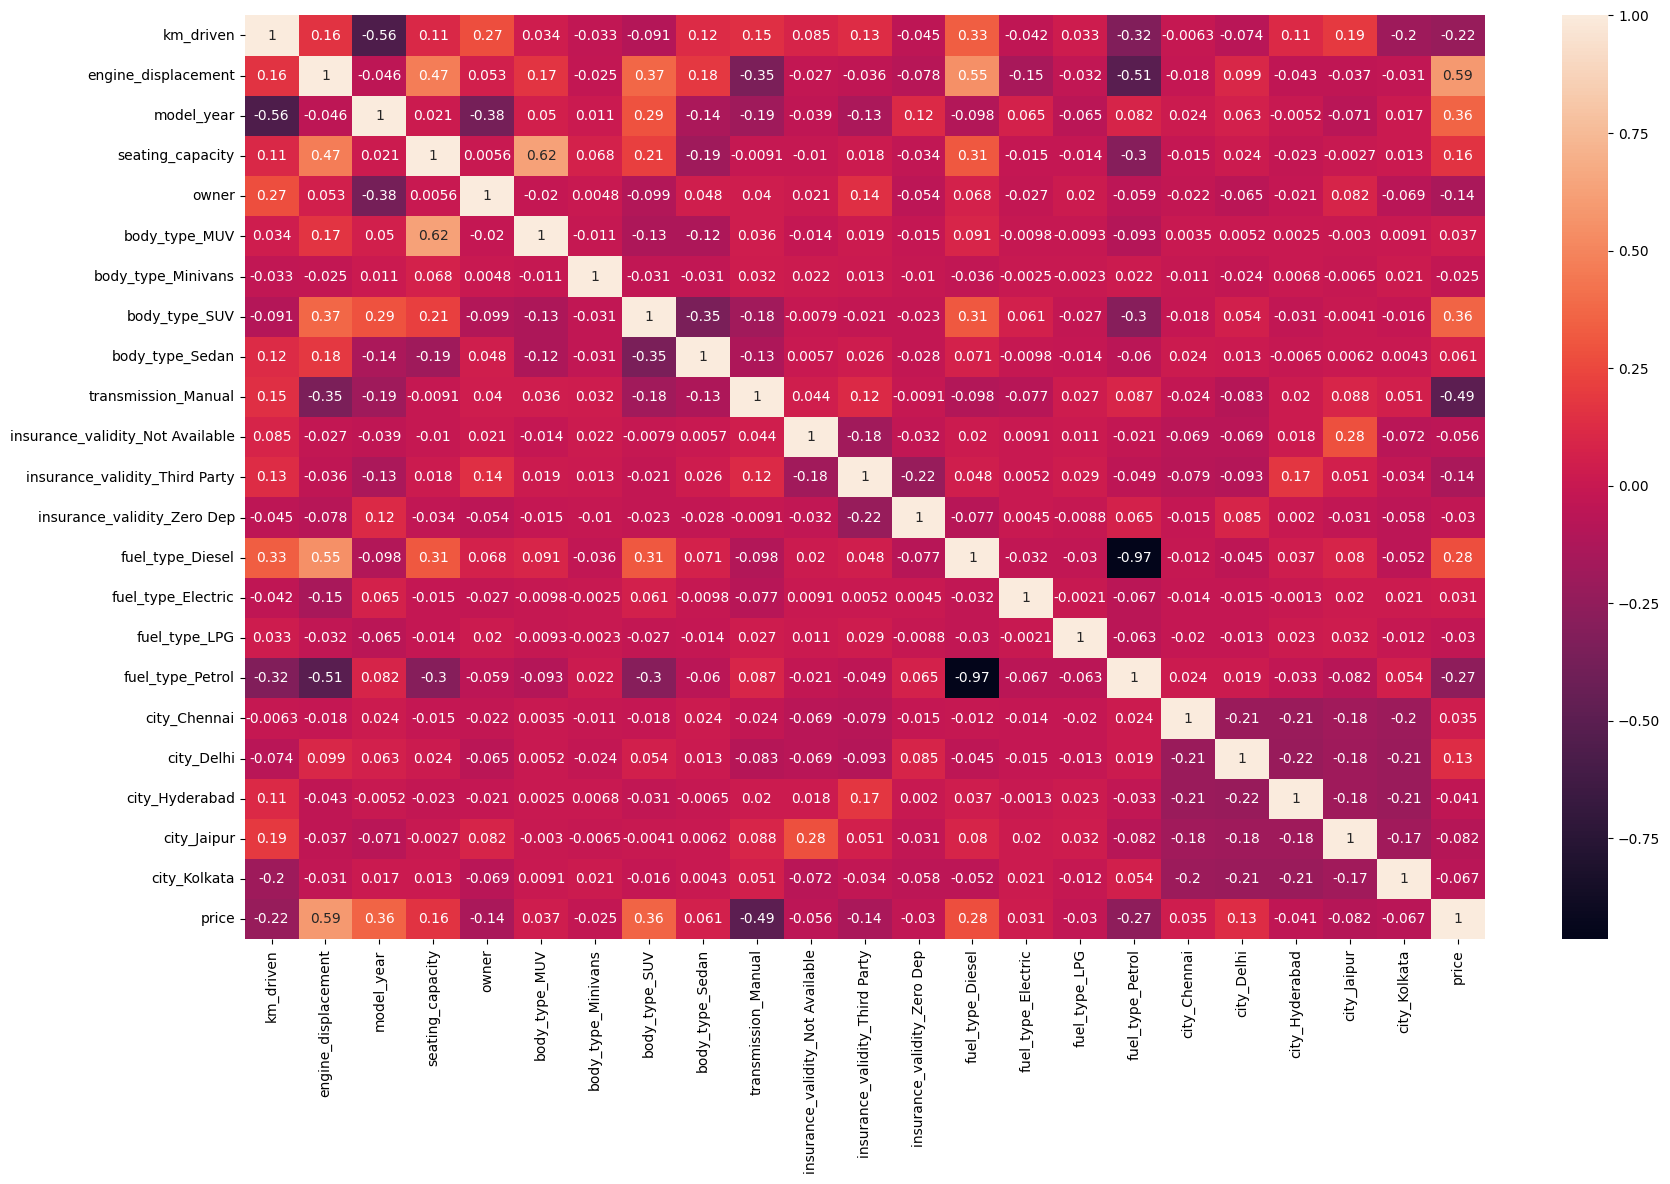

In [163]:
cols = list(df5.columns[:22]) + [df5.columns[-1]]
cm = df5[cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))
sns.heatmap(cm, annot=True)

In [164]:
df5.head()

,km_driven,engine_displacement,model_year,seating_capacity,owner,body_type_MUV,body_type_Minivans,body_type_SUV,body_type_Sedan,transmission_Manual,insurance_validity_Not Available,insurance_validity_Third Party,insurance_validity_Zero Dep,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,model_variant_Audi A3 | 35 TDI Technology,model_variant_Audi A3 | 35 TFSI Premium Plus,model_variant_Audi A3 | Variant,model_variant_Audi A4 | 1.8 TFSI,model_variant_Audi A4 | 2.0 TDI,model_variant_Audi A4 | 2.0 TDI Premium Plus,model_variant_Audi A4 | 2.0 TDI Premium Sport Limited Edition,model_variant_Audi A4 | 35 TDI Premium,model_variant_Audi A4 | 35 TDI Premium Plus,model_variant_Audi A4 | New 2.0 TDI Multitronic,model_variant_Audi A4 | Technology,model_variant_Audi A4 | Variant,model_variant_Audi A6 | 2.0 TDI,model_variant_Audi A6 | 2.0 TDI Premium Plus,model_variant_Audi A6 | 2.0 TDI Technology,model_variant_Audi A6 | 3.0 TDI Quattro Premium Plus,model_variant_Audi A6 | 35 TDI,model_variant_Audi A6 | 35 TDI Premium,model_variant_Audi A6 | 35 TDI Technology,model_variant_Audi A6 | 35 TFSI,model_variant_Audi A6 | 35 TFSI Matrix,model_variant_Audi A6 | Variant,model_variant_Audi Q3 | 2.0 TDI,model_variant_Audi Q3 | 2.0 TDI Quattro Premium Plus,model_variant_Audi Q3 | 30 TDI,model_variant_Audi Q3 | 30 TFSI Premium FWD,model_variant_Audi Q3 | 35 TDI Quattro Premium,model_variant_Audi Q3 | 35 TDI Quattro Premium Plus,model_variant_Audi Q3 | Variant,model_variant_Audi Q5 | 2.0 TDI,model_variant_Audi Q5 | 2.0 TFSI Quattro,model_variant_Audi Q5 | 30 TDI quattro Premium,model_variant_Audi Q5 | Variant,model_variant_Audi Q7 | 3.0 TDI Quattro Premium Plus,model_variant_Audi Q7 | 3.0 TDI Quattro Technology,model_variant_Audi Q7 | 3.0 TDI quattro,model_variant_Audi Q7 | 45 TDI Quattro Premium Plus,model_variant_Audi Q7 | 45 TDI Quattro Technology,model_variant_Audi Q7 | Variant,model_variant_BMW 3 Series GT | Luxury Line,model_variant_BMW 3 Series GT | M Sport Petrol,model_variant_BMW 3 Series GT | Sport,model_variant_BMW 3 Series | 320d,model_variant_BMW 3 Series | 320d Highline,model_variant_BMW 3 Series | 320d Luxury Line,model_variant_BMW 3 Series | 320d Prestige,model_variant_BMW 3 Series | 320d Sport Line,model_variant_BMW 3 Series | 330i M Sport,model_variant_BMW 3 Series | Variant,model_variant_BMW 5 Series | 520d Luxury Line,model_variant_BMW 5 Series | 520d Sedan,model_variant_BMW 5 Series | 525d,model_variant_BMW 5 Series | 530d M Sport,model_variant_BMW 5 Series | 530i M Sport,model_variant_BMW 5 Series | Variant,model_variant_BMW X1 | M Sport sDrive 20d,model_variant_BMW X1 | Variant,model_variant_BMW X1 | sDrive 20D xLine,model_variant_BMW X1 | sDrive 20d M Sport,model_variant_BMW X1 | sDrive 20d Sportline,model_variant_BMW X1 | sDrive 20d xLine,model_variant_BMW X1 | sDrive18d M Sport,model_variant_BMW X1 | sDrive20d,model_variant_BMW X1 | sDrive20d Expedition,model_variant_BMW X3 | 2.0d SAV,model_variant_BMW X3 | Variant,model_variant_BMW X3 | xDrive 20d Luxury Line,model_variant_BMW X3 | xDrive 30i Luxury Line,model_variant_BMW X3 | xDrive20d,model_variant_BMW X3 | xDrive20d xLine,model_variant_BMW X3 | xDrive30d M Sport,model_variant_BMW X5 | Variant,model_variant_BMW X5 | xDrive 30d,model_variant_BMW X5 | xDrive 30d Design Pure Experience 5 Seater,model_variant_BMW X5 | xDrive 30d xLine,model_variant_Chevrolet Beat | Diesel LS,model_variant_Chevrolet Beat | Diesel LT,model_variant_Chevrolet Beat | LS,model_variant_Chevrolet Beat | LT,model_variant_Chevrolet Beat | PS,model_variant_Chevrolet Cruze | LTZ,model_variant_Chevrolet Cruze | LTZ AT,model_variant_Chevrolet Spark | 1.0 LS,model_variant_Chevrolet Spark | Variant,model_variant_Datsun GO Plus | T,model_variant_Datsun GO Plus | T BSIV,model_variant_Datsun GO Plus | T Petrol,model_variant_Datsun GO Plus | Variant,model_variant_Datsun GO | T,model_variant_Datsun GO | T BSIV,model_variant_Datsun GO | 

In [165]:
pd.set_option('display.max_rows', None)

In [166]:
correlation_with_target = df5.corr()['price'].drop('price')

correlation_df = correlation_with_target.reset_index()
correlation_df.columns = ['Feature', 'Correlation_with_Price']

correlation_df = correlation_df.sort_values(by='Correlation_with_Price', ascending=False)

correlation_df

,Feature,Correlation_with_Price
1,engine_displacement,0.59
1058,model_variant_Other | High Variant,0.43
7,body_type_SUV,0.36
2,model_year,0.36
13,fuel_type_Diesel,0.28
1033,model_variant_Mercedes-Benz GLE | 300d BSVI,0.20
1036,model_variant_Mercedes-Benz GLS | Variant,0.17
3,seating_capacity,0.16
71,model_variant_BMW 5 Series | 520d Luxury Line,0.14
1028,model_variant_Mercedes-Benz GLC | 220d 4MATIC,0.13


In [167]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_VIF(df):
    vif_df = pd.DataFrame()
    vif_df['column'] = df.columns
    vif_df['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    vif_df_d = vif_df.sort_values(by='VIF', ascending=False).reset_index(drop=True)

    return vif_df, vif_df_d

X = df5[df5.columns[:22]]

calculate_VIF(X)

(                              column   VIF
 0                          km_driven  6.52
 1                engine_displacement 25.94
 2                         model_year 13.42
 3                   seating_capacity 11.51
 4                              owner  1.57
 5                      body_type_MUV  2.01
 6                 body_type_Minivans  1.03
 7                      body_type_SUV  2.62
 8                    body_type_Sedan  2.08
 9                transmission_Manual  4.39
 10  insurance_validity_Not Available  1.19
 11    insurance_validity_Third Party  2.70
 12       insurance_validity_Zero Dep  1.13
 13                  fuel_type_Diesel 16.18
 14                fuel_type_Electric  1.09
 15                     fuel_type_LPG  1.07
 16                  fuel_type_Petrol 24.65
 17                      city_Chennai  1.97
 18                        city_Delhi  2.01
 19                    city_Hyderabad  2.09
 20                       city_Jaipur  1.93
 21                      city_Ko

##### Model

In [168]:
import pandas as pd

df = pd.read_excel('preped.xlsx')

print(df.shape)
df.head()

(8082, 1388)


,km_driven,engine_displacement,model_year,seating_capacity,owner,body_type_MUV,body_type_Minivans,body_type_SUV,body_type_Sedan,transmission_Manual,insurance_validity_Not Available,insurance_validity_Third Party,insurance_validity_Zero Dep,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,model_variant_Audi A3 | 35 TDI Technology,model_variant_Audi A3 | 35 TFSI Premium Plus,model_variant_Audi A3 | Variant,model_variant_Audi A4 | 1.8 TFSI,model_variant_Audi A4 | 2.0 TDI,model_variant_Audi A4 | 2.0 TDI Premium Plus,model_variant_Audi A4 | 2.0 TDI Premium Sport Limited Edition,model_variant_Audi A4 | 35 TDI Premium,model_variant_Audi A4 | 35 TDI Premium Plus,model_variant_Audi A4 | New 2.0 TDI Multitronic,model_variant_Audi A4 | Technology,model_variant_Audi A4 | Variant,model_variant_Audi A6 | 2.0 TDI,model_variant_Audi A6 | 2.0 TDI Premium Plus,model_variant_Audi A6 | 2.0 TDI Technology,model_variant_Audi A6 | 3.0 TDI Quattro Premium Plus,model_variant_Audi A6 | 35 TDI,model_variant_Audi A6 | 35 TDI Premium,model_variant_Audi A6 | 35 TDI Technology,model_variant_Audi A6 | 35 TFSI,model_variant_Audi A6 | 35 TFSI Matrix,model_variant_Audi A6 | Variant,model_variant_Audi Q3 | 2.0 TDI,model_variant_Audi Q3 | 2.0 TDI Quattro Premium Plus,model_variant_Audi Q3 | 30 TDI,model_variant_Audi Q3 | 30 TFSI Premium FWD,model_variant_Audi Q3 | 35 TDI Quattro Premium,model_variant_Audi Q3 | 35 TDI Quattro Premium Plus,model_variant_Audi Q3 | Variant,model_variant_Audi Q5 | 2.0 TDI,model_variant_Audi Q5 | 2.0 TFSI Quattro,model_variant_Audi Q5 | 30 TDI quattro Premium,model_variant_Audi Q5 | Variant,model_variant_Audi Q7 | 3.0 TDI Quattro Premium Plus,model_variant_Audi Q7 | 3.0 TDI Quattro Technology,model_variant_Audi Q7 | 3.0 TDI quattro,model_variant_Audi Q7 | 45 TDI Quattro Premium Plus,model_variant_Audi Q7 | 45 TDI Quattro Technology,model_variant_Audi Q7 | Variant,model_variant_BMW 3 Series GT | Luxury Line,model_variant_BMW 3 Series GT | M Sport Petrol,model_variant_BMW 3 Series GT | Sport,model_variant_BMW 3 Series | 320d,model_variant_BMW 3 Series | 320d Highline,model_variant_BMW 3 Series | 320d Luxury Line,model_variant_BMW 3 Series | 320d Prestige,model_variant_BMW 3 Series | 320d Sport Line,model_variant_BMW 3 Series | 330i M Sport,model_variant_BMW 3 Series | Variant,model_variant_BMW 5 Series | 520d Luxury Line,model_variant_BMW 5 Series | 520d Sedan,model_variant_BMW 5 Series | 525d,model_variant_BMW 5 Series | 530d M Sport,model_variant_BMW 5 Series | 530i M Sport,model_variant_BMW 5 Series | Variant,model_variant_BMW X1 | M Sport sDrive 20d,model_variant_BMW X1 | Variant,model_variant_BMW X1 | sDrive 20D xLine,model_variant_BMW X1 | sDrive 20d M Sport,model_variant_BMW X1 | sDrive 20d Sportline,model_variant_BMW X1 | sDrive 20d xLine,model_variant_BMW X1 | sDrive18d M Sport,model_variant_BMW X1 | sDrive20d,model_variant_BMW X1 | sDrive20d Expedition,model_variant_BMW X3 | 2.0d SAV,model_variant_BMW X3 | Variant,model_variant_BMW X3 | xDrive 20d Luxury Line,model_variant_BMW X3 | xDrive 30i Luxury Line,model_variant_BMW X3 | xDrive20d,model_variant_BMW X3 | xDrive20d xLine,model_variant_BMW X3 | xDrive30d M Sport,model_variant_BMW X5 | Variant,model_variant_BMW X5 | xDrive 30d,model_variant_BMW X5 | xDrive 30d Design Pure Experience 5 Seater,model_variant_BMW X5 | xDrive 30d xLine,model_variant_Chevrolet Beat | Diesel LS,model_variant_Chevrolet Beat | Diesel LT,model_variant_Chevrolet Beat | LS,model_variant_Chevrolet Beat | LT,model_variant_Chevrolet Beat | PS,model_variant_Chevrolet Cruze | LTZ,model_variant_Chevrolet Cruze | LTZ AT,model_variant_Chevrolet Spark | 1.0 LS,model_variant_Chevrolet Spark | Variant,model_variant_Datsun GO Plus | T,model_variant_Datsun GO Plus | T BSIV,model_variant_Datsun GO Plus | T Petrol,model_variant_Datsun GO Plus | Variant,model_variant_Datsun GO | T,model_variant_Datsun GO | T BSIV,model_variant_Datsun GO | 

In [169]:
from sklearn.model_selection import train_test_split

X = df.drop(['price'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [170]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR  
from sklearn.metrics import mean_squared_error


models = [LinearRegression(), Ridge(), XGBRegressor(), DecisionTreeRegressor(), RandomForestRegressor(), SVR()]

for model in models:
    model_name = model.__class__.__name__
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    
    print(f"Model: {model_name}")
    print(f"Train Score: {train_score:.4f}")
    print(f"Test Score: {test_score:.4f}")
    print(f"MSE Train: {mse_train:.4f}")
    print(f"MSE Test: {mse_test:.4f}")
    print('______________________')

Model: LinearRegression
Train Score: 0.9161
Test Score: 0.7750
MSE Train: 0.0005
MSE Test: 0.0012
______________________
Model: Ridge
Train Score: 0.8922
Test Score: 0.7990
MSE Train: 0.0006
MSE Test: 0.0011
______________________
Model: XGBRegressor
Train Score: 0.9758
Test Score: 0.8939
MSE Train: 0.0001
MSE Test: 0.0006
______________________
Model: DecisionTreeRegressor
Train Score: 0.9997
Test Score: 0.8170
MSE Train: 0.0000
MSE Test: 0.0010
______________________
Model: RandomForestRegressor
Train Score: 0.9876
Test Score: 0.8924
MSE Train: 0.0001
MSE Test: 0.0006
______________________
Model: SVR
Train Score: 0.5571
Test Score: 0.4101
MSE Train: 0.0026
MSE Test: 0.0031
______________________


Hyper Parameter Tuning and Grid Search CV

In [171]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_excel('preped.xlsx')

X = df.drop(['price'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define model
xgb = XGBRegressor()

# Define hyperparameters grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Setup GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',  # Use R2 as scoring metric
    cv=5,          # 5-fold CV
    verbose=2,
    n_jobs=-1      # Use all cores
)

# Run grid search
grid_search.fit(X_train, y_train)

# Best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best R2 score: ", grid_search.best_score_)
best_model = grid_search.best_estimator_

test_r2 = best_model.score(X_test, y_test)
print(f"Test R2 score: {test_r2:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found:  {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best R2 score:  0.9077395265740584
Test R2 score: 0.9010


In [ ]:

import pandas as pd

b_df = pd.read_excel('bangalore_cars.xlsx')
c_df = pd.read_excel('chennai_cars.xlsx')
d_df = pd.read_excel('delhi_cars.xlsx')
h_df = pd.read_excel('hyderabad_cars.xlsx')
j_df = pd.read_excel('jaipur_cars.xlsx')
k_df = pd.read_excel('kolkata_cars.xlsx')
##### Add City
b_df['City'] = 'Bangalore'
c_df['City'] = 'Chennai'
d_df['City'] = 'Delhi'
h_df['City'] = 'Hyderabad'
j_df['City'] = 'Jaipur'
k_df['City'] = 'Kolkata'
##### Concat
df_merged = pd.concat([b_df, c_df, d_df, h_df, j_df, k_df], ignore_index=True)

import ast
df_merged['new_car_detail'] = df_merged['new_car_detail'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_new_car_detail = pd.json_normalize(df_merged['new_car_detail'])
df_merged['new_car_overview'] = df_merged['new_car_overview'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

overview_dfs = []

for row in df_merged['new_car_overview']:
    keys = []
    values = []
    
    if row and 'top' in row and isinstance(row['top'], list):
        for item in row['top']:
            keys.append(item['key'])
            values.append(item['value'])
        
        temp_df = pd.DataFrame([values], columns=keys)
        overview_dfs.append(temp_df)
    else:
        overview_dfs.append(pd.DataFrame())

df_new_car_overview = pd.concat(overview_dfs, ignore_index=True)

df = pd.concat([df_new_car_detail, df_new_car_overview,  df_merged[['City']]], axis=1)

##### Handling Missing Values
df.drop(['it', 'owner', 'centralVariantId', 'priceActual', 'priceSaving', 'trendingText.imgUrl',
       'trendingText.heading', 'trendingText.desc', 'Registration Year', 'Kms Driven', 'RTO',
       'Ownership', 'ft', 'Transmission',
       'Year of Manufacture', 'priceFixedText'], axis=1, inplace=True)
df = df.rename(columns={'bt': 'body_type', 'km': 'km_driven', 'ownerNo': 'owner', 'modelYear': 'model_year', 'variantName': 'variant_name',
                        'Insurance Validity': 'insurance_validity', 'Fuel Type': 'fuel_type', 'Seats': 'seating_capacity',
                        'Engine Displacement': 'engine_displacement', 'City': 'city'})


df['variant_name'] = df['variant_name'].replace({'Petrol': 'XV D BSIV'})
# Use ffill() and bfill() directly to fill nulls
df['seating_capacity'] = df.groupby('variant_name')['seating_capacity'].transform(lambda x: x.ffill().bfill())
df['engine_displacement'] = df.groupby('variant_name')['engine_displacement'].transform(lambda x: x.ffill().bfill())
df['seating_capacity'] = df.groupby('model')['seating_capacity'].transform(lambda x: x.ffill().bfill())
df['engine_displacement'] = df.groupby('model')['engine_displacement'].transform(lambda x: x.ffill().bfill())
df = df.dropna()

##### Formatting
df_1 = df.copy()
df_1[df_1['body_type'].str.strip() == '']
df_1['body_type'] = df_1['body_type'].replace({'': None})
df_1['body_type'] = df_1.groupby('model')['body_type'].transform(lambda x: x.ffill().bfill())
df_1['body_type'] = df_1['body_type'].replace({'Hybrids': 'SUV'})
df_1['body_type'] = df_1['body_type'].replace({'Wagon': 'Hatchback'})
df_1['km_driven'] = df_1['km_driven'].str.replace(',', '').astype(int)
df_1[df_1['owner'] == 0]
df_1['owner'] = df_1['owner'].replace({0: None})
df_1['owner'] = df_1['owner'].fillna(df_1['owner'].mode().iloc[0])
df_1['insurance_validity'] = df_1['insurance_validity'].replace({'Third Party insurance': 'Third Party', '1': 'Third Party', '2': 'Third Party'})
df_1['seating_capacity'] = df_1['seating_capacity'].str.replace('Seats', '', case=False, regex=True).str.strip()
df_1['engine_displacement'] = df_1['engine_displacement'].str.replace('cc', '', case=False, regex=True).str.strip()

def clean_price(value):
    if pd.isna(value):
        return None
    
    value = str(value).replace('₹', '').replace(',', '').strip().lower()

    if 'lakh' in value:
        return float(value.replace('lakh', '').strip()) * 1e5
    elif 'crore' in value:
        return float(value.replace('crore', '').strip()) * 1e7
    elif 'thousand' in value:
        return float(value.replace('thousand', '').strip()) * 1e3
    else:
        try:
            return float(value)
        except:
            return None  # for unexpected formats

# Apply to the price column
df_1['price'] = df_1['price'].apply(clean_price)

df_1['price'] = df_1['price'].astype(int)
df_1['seating_capacity'] = df_1['seating_capacity'].astype(int)
df_1['engine_displacement'] = df_1['engine_displacement'].astype(int)

df_1 = df_1.dropna()

##### Outliers
df_2 = df_1.copy()

df_2 = df_2[df_2['body_type'] != 'Convertibles']
df_2 = df_2[df_2['body_type'] != 'Coupe']
df_2 = df_2[df_2['body_type'] != 'Pickup Trucks']

df_2 = df_2[df_2['km_driven'] != 0]
df_2 = df_2[df_2['km_driven'] < 200000]
df_2 = df_2[(df_2['seating_capacity'] >= 4) & (df_2['seating_capacity'] <= 8)]
df_2 = df_2[df_2['model_year'] > 2005]

df_2.loc[
    (df_2['fuel_type'] == 'Electric') &
    (df_2['transmission'] == 'Automatic') &
    (df_2['engine_displacement'] != 0),
    'engine_displacement'
] = 0

df_2 = df_2[(df_2['engine_displacement'] <= 3500)]

df_2 = df_2[(df_2['price'] < 15000000)]

oem_counts = df_2['oem'].value_counts()
valid_oems = oem_counts[oem_counts >= 10].index
df_2 = df_2[df_2['oem'].isin(valid_oems)]

model_counts = df_2['model'].value_counts()
valid_oems = model_counts[model_counts >= 3].index
df_2 = df_2[df_2['model'].isin(valid_oems)]

##### Feature Engineering
df3 = df_2.copy()

def generate_model_variant(row, rare_models):
    if row['model'] in rare_models:
        if row['price'] < 500000:
            return 'Other | Low Variant'
        elif 500000 <= row['price'] < 2000000:
            return 'Other | Mid Variant'
        else:
            return 'Other | High Variant'
    else:
        return f"{row['model']} | {row['variant_name']}"
    

model_counts = df3['model'].value_counts()
rare_models = model_counts[model_counts < 10].index.tolist()

df3['model_variant'] = df3.apply(lambda row: generate_model_variant(row, rare_models), axis=1)

model_variant_counts = df3['model_variant'].value_counts()
rare_model_variant = model_variant_counts[model_variant_counts == 1].index

model_counts = df3['model'].value_counts()

def updated_variant(row):
    if row['model_variant'] in rare_model_variant:
        if model_counts[row['model']] > 1:
            return f"{row['model']} | Variant"
        else:
            return f"{row['oem']} | Other"  
    else:
        return row['model_variant']

df3['model_variant'] = df3.apply(updated_variant, axis=1)

variant_counts = df3['model_variant'].value_counts()
df3 = df3[df3['model_variant'].isin(variant_counts[variant_counts > 1].index)]

df3.drop(['oem', 'model', 'variant_name'], axis=1, inplace=True)


##### Encoding & Scaling

df4 = df3.copy()

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

categorical_cols = ['body_type', 'transmission', 'insurance_validity', 'fuel_type', 'city', 'model_variant']
numerical_cols = ['km_driven', 'owner', 'model_year', 'price', 'seating_capacity', 'engine_displacement']
cols_to_normalize = ['km_driven', 'engine_displacement', 'model_year', 'seating_capacity', 'owner']


## Encoding the Categorical Columns
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoded_array = encoder.fit_transform(df4[categorical_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols))
encoded_df = encoded_df.astype(int)

## Scaling the Numerical Columns 
scaler = MinMaxScaler()
scaled_numerical = pd.DataFrame(scaler.fit_transform(df4[cols_to_normalize]), columns=cols_to_normalize)

# ## Scaling the Target Column 
target_column = 'price'
target_scaler = MinMaxScaler()
df4[target_column] = target_scaler.fit_transform(df4[[target_column]])


## Combining the data frames
df4 = pd.concat([scaled_numerical, encoded_df, df4[target_column]], axis=1)

df4 = df4.dropna()

df = df4.copy()

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_excel('preped.xlsx')

X = df.drop(['price'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define model
xgb = XGBRegressor()

# Define hyperparameters grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Setup GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',  # Use R2 as scoring metric
    cv=5,          # 5-fold CV
    verbose=2,
    n_jobs=-1      # Use all cores
)

# Run grid search
grid_search.fit(X_train, y_train)

# Best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best R2 score: ", grid_search.best_score_)
best_model = grid_search.best_estimator_

test_r2 = best_model.score(X_test, y_test)
print(f"Test R2 score: {test_r2:.4f}")

In [172]:
import joblib
from xgboost import XGBRegressor

# 1. Final training
best_params = grid_search.best_params_
final_model = XGBRegressor(**best_params)
final_model.fit(X_train, y_train)

# 2. Save model
joblib.dump(final_model, 'xgb_model.pkl')

# 3. Save encoder and scalers
joblib.dump(encoder, 'encoder.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(target_scaler, 'target_scaler.pkl')


['target_scaler.pkl']